# Ensemble Learning Project: EasyVisa

## Problem Statment:

Problem Statement:
As a Data Scientist at EasyVisa, I have been tasked with addressing a key challenge faced by the Office of Foreign Labor Certification (OFLC) in the United States. With a growing number of visa certification applications—over 775,979 applications processed for 1,699,957 positions in FY 2016 alone—the manual review process has become increasingly time-consuming and inefficient.

**To assist OFLC, I am responsible for developing a Machine Learning-based classification model that will:**

1.**Facilitate the visa approval process** by automatically shortlisting applicants with a higher likelihood of visa approval.

2.**Recommend whether a visa should be certified or denied** by analyzing the key factors that influence visa certification outcomes based on the employee and employer attributes provided.
The goal is to create a data-driven solution that helps streamline visa decision-making, ensuring efficient processing of applications while complying with US labor regulations and safeguarding the interests of both US workers and foreign applicants.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries, creating dataframe and functions

In [1]:
#libraries to read and manipulate data
import numpy as np
import pandas as pd

#libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

#libraries for model building and tuning
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,RandomForestClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#libraries for metrics and statistics
from sklearn import metrics
import scipy.stats as stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#reading csv file into a pandas Dataframe
visa = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')
# copying data to another varaible to preserve original data
df = visa.copy()

In [4]:
#format numeric data for easier readability
pd.set_option(
    "display.float_format", lambda x: "%.2f" % x
)  # to display numbers rounded off to 2 decimal places

In [5]:
# function to create labeled barplots

def labeled_barplot(data, feature, feature_2, order, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    feature_2: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    ax = sns.countplot(
        data=data,
        x=feature,
        palette='viridis',
        order=order,
        hue=feature_2,
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 5),
            textcoords="offset points"
        )  # annotate the percentage

    plt.show()  # show the plot

In [6]:
# function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize=(16, 6), kde=False, bins=None, hue=None):
    """
    Combines boxplot and histogram

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (16,6))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True,
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter",
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

## Data Overview

In [8]:
# print first five rows
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [9]:
# print last five rows
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [10]:
# print shape of dataset
df.shape

(25480, 12)

#### Observations
- Dataset has 25,480 rows and 12 columns.

In [11]:
# print the data types of the columns within the datset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [12]:
# checking for duplicate values
df[df.duplicated()]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


* There are no missing or duplicate values in the dataset.
* We should convert the object type columns to categories, which reduces the memory required to store the dataframe.

In [13]:
# convert all columns with dtype object into category
for col in df.columns[df.dtypes=='object']:
    df[col] = df[col].astype('category')

- There are 9 columns of the dtype object, 1 columns of the dtype float64, and 2 columns of the dtype int64.
- The target variable for the models is *case_status*.
- *case_id* is a randomly assigned by INA for each case, which should not provide any material information for model building.

In [14]:
# drop the column *case_id* from the dataframe
df.drop(labels='case_id', axis=1, inplace=True)

In [15]:
# confirm conversions and dropped variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


* The memory required to store the dataframe is now ~800kB, a third the size of the original dataframe.

## Exploratory Data Analysis (EDA)

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

#### 1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

In [16]:
#group data by education_of_employee and count the numbers of each case_status for each category
df.groupby('education_of_employee')['case_status'].value_counts()

education_of_employee  case_status
Bachelor's             Certified      6367
                       Denied         3867
Doctorate              Certified      1912
                       Denied          280
High School            Denied         2256
                       Certified      1164
Master's               Certified      7575
                       Denied         2059
Name: count, dtype: int64

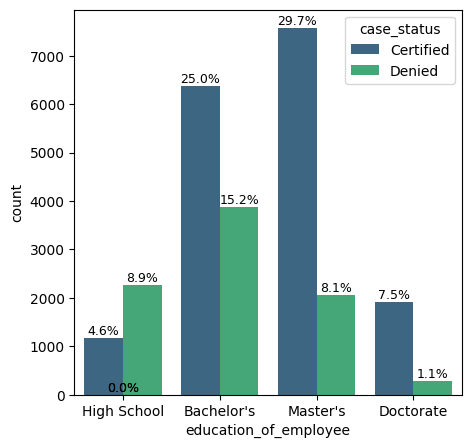

In [17]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df,'education_of_employee','case_status', order=["High School","Bachelor's","Master's","Doctorate"], perc=True)

* As the graph aboves shows, the ratio of applications being certified versus denied increases considerably as an applicant's highest level of education achieved increases.
* The ratio of an applicant with a high school diploma being approved versus denied is ~1:2, whereas the same ratio for an applicant with a doctorate is ~7:1.

#### 2. How does the visa status vary across different continents?

In [18]:
#group data by continent and count the numbers of each case_status for each category
df.groupby('continent')['case_status'].value_counts()

continent      case_status
Africa         Certified        397
               Denied           154
Asia           Certified      11012
               Denied          5849
Europe         Certified       2957
               Denied           775
North America  Certified       2037
               Denied          1255
Oceania        Certified        122
               Denied            70
South America  Certified        493
               Denied           359
Name: count, dtype: int64

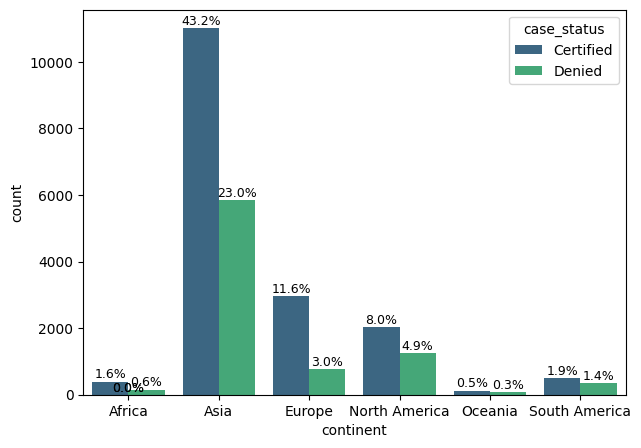

In [19]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df,'continent','case_status', order=None, perc=True)

* Applicants from Asia comprise ~2/3 of all applications and these applicants have almost a 2:1 ratio of approvals to denials.
* An application from a European applicant has the best ratio of approvals to denials (~4:1).

#### 3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

In [20]:
#group data by has_job_experience and count the numbers of each case_status for each category
df.groupby('has_job_experience')['case_status'].value_counts()

has_job_experience  case_status
N                   Certified       5994
                    Denied          4684
Y                   Certified      11024
                    Denied          3778
Name: count, dtype: int64

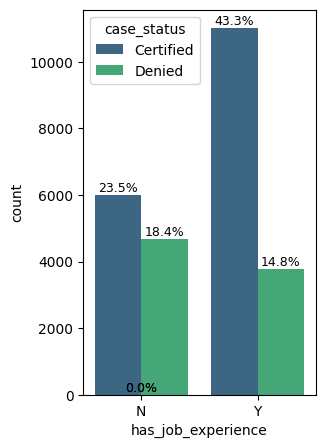

In [21]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df,'has_job_experience','case_status', order=None, perc=True)

* Applicants with job experience have a ratio of approved to denied applications of ~3:1, whereas the same ratio for applicants without job experience have around a 5:4 ratio (i.e., approximately equivalent).

#### 4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

In [22]:
#group data by unit_of_wage and count the numbers of each case_status for each category
df.groupby('unit_of_wage')['case_status'].value_counts()

unit_of_wage  case_status
Hour          Denied          1410
              Certified        747
Month         Certified         55
              Denied            34
Week          Certified        169
              Denied           103
Year          Certified      16047
              Denied          6915
Name: count, dtype: int64

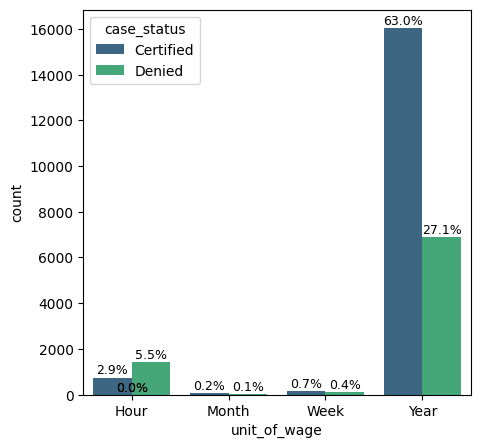

In [23]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df,'unit_of_wage','case_status', order=None, perc=True)

* Applicants who are applying to work in a job with an hourly rate have a ratio of approved versus denied applications of ~1:2. Additionally, these applicants comprise only ~8% of all applications, but comprise ~17% of all denials.
* Applicants from any other *unit_of_wage* category have a ratio of ~2:1, with applications for jobs with annual salaries showing nearly a 2.5:1 ratio of approvals to denials.

#### 5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

In [24]:
#group data by unit_of_wage and calculate the mean prevailing_wage for each category
df.groupby('unit_of_wage')['prevailing_wage'].mean()

,prevailing_wage
unit_of_wage,
Hour,414.57
Month,87592.86
Week,85606.82
Year,81228.08


* The data shows that the *unit_of_wage* 'Hour' is a per-day amount, whearas the other three *unit_of_wage* categories are an annual salary amount.

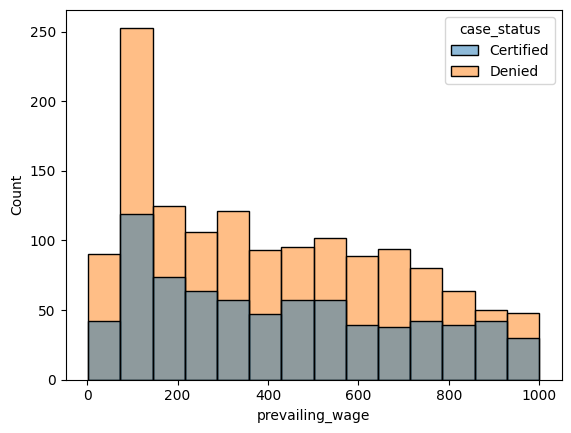

In [25]:
#create a dataframe only of workers applying for jobs with a *unit_wage* of 'Hour'
df_hourly = df[df.unit_of_wage=='Hour']
#show a distribution of the *prevailing_wage* within this dataframe, along with the ratio of *case_status* within each bin
sns.histplot(data=df_hourly, x='prevailing_wage', hue='case_status')
plt.show()

In [26]:
#create bins that categorize applicants by the per-day wage of the job he or she is applying for
bins = list(np.arange(0,1100,200))
#assign each applicant to a category
df_hourly['income_per_day'] = pd.cut(df_hourly['prevailing_wage'], bins)
df_hourly.groupby('income_per_day')['case_status'].value_counts()

income_per_day  case_status
(0, 200]        Denied         448
                Certified      219
(200, 400]      Denied         301
                Certified      166
(400, 600]      Denied         274
                Certified      144
(600, 800]      Denied         239
                Certified      116
(800, 1000]     Denied         148
                Certified      102
Name: count, dtype: int64

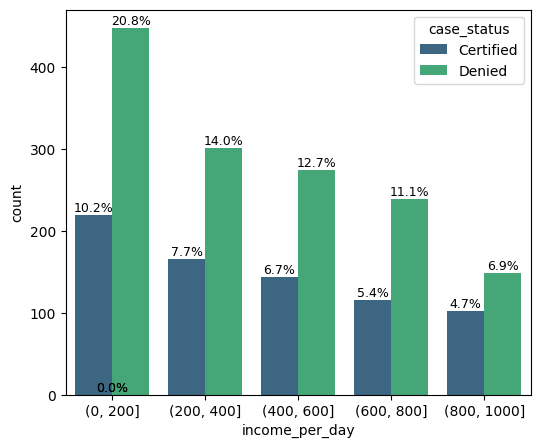

In [27]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df_hourly,'income_per_day','case_status',perc=True,order=None)

* As the graphs above show, even within applicants for jobs with an 'Hour' *prevailing_wage*, the ratio of approved to denied applications increases considerably as *prevailing_wage* increases.
* Even at the highest *income_per_day* category, an application is still more likely to be denied than approved.

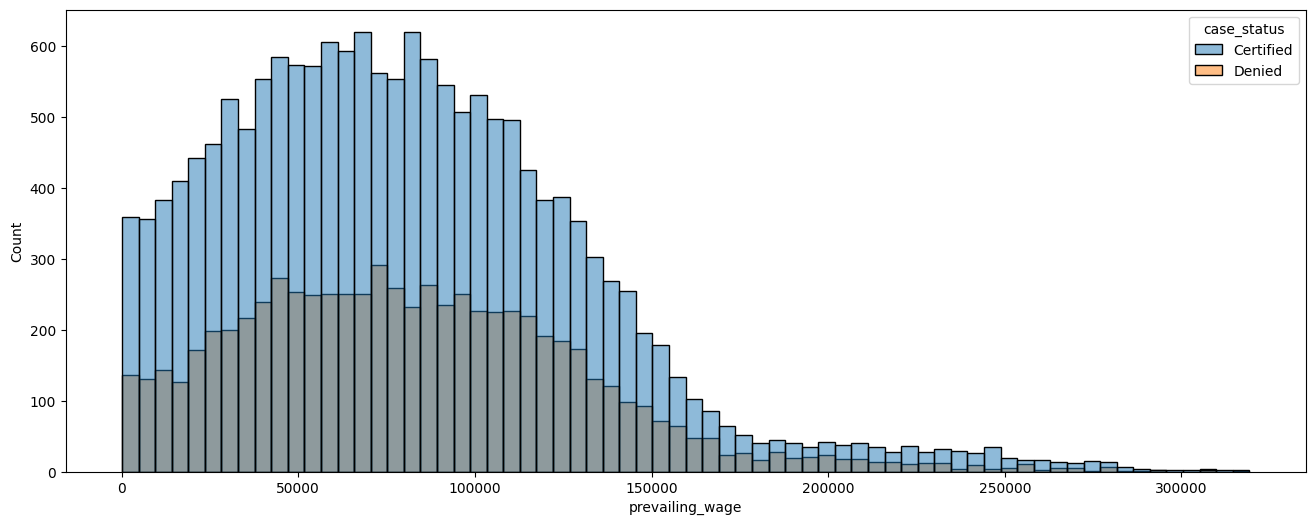

In [28]:
#create a new dataframe of only those applicants applying for jobs with annual salaries (i.e., not 'Hour')
df_annual = df[df.unit_of_wage != "Hour"]
#show the distribution of annual salaries, along with ratio of *case_status* within each bin
plt.figure(figsize=(16,6))
sns.histplot(data=df_annual, x='prevailing_wage', hue='case_status')
plt.show()

* The distribution of wages is (as expected) right skewed, indicating a long-tail of jobs with annual salaries above 150,000 dollars.
* As the distribution above shows, the ratio of approved to denied applications remains approximately equivalent across the range of wages.

In [29]:
#create bins to categorize a job by its annual salary, which indicates how well paying the job is
bins = [0,25000,50000,75000,100000,125000,np.inf]
names = ['$0-25k','$25k-50k','$50k-75k','$75k-100k','$100k-125k','$125k+']
#assign an applicant to a category
df_annual['income_per_year'] = pd.cut(df_annual['prevailing_wage'], bins, labels=names)
df_annual.groupby('income_per_year')['case_status'].value_counts()

income_per_year  case_status
$0-25k           Certified      2090
                 Denied          761
$25k-50k         Certified      2839
                 Denied         1237
$50k-75k         Certified      3133
                 Denied         1372
$75k-100k        Certified      3014
                 Denied         1318
$100k-125k       Certified      2410
                 Denied         1138
$125k+           Certified      2785
                 Denied         1226
Name: count, dtype: int64

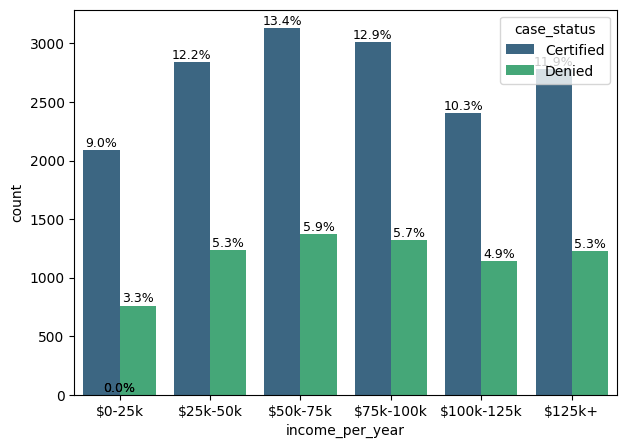

In [30]:
#create a plot of the data above, but additionally with the percent of each group within the total number of cases
labeled_barplot(df_annual,'income_per_year','case_status',perc=True,order=None)

* In support of the observation above, there does not appear to be a significant change in ratio of approved to denied applications as *income_per_year* increases. To the contrary, the ratio may actually decrease as this *prevailing_wage* increases.
* For applications for jobs with an *income_per_year* wage, the highest concentration of applications is for jobs with 50,000 to 75,000 dollars per year in salary.

## Data Preprocessing

- Feature engineering
- Outlier detection and treatment

In [31]:
#show the number of rows with a value of no_of_employees less than 0, which is not a possible value
df[df.no_of_employees<0].shape

(33, 11)

In [32]:
#drop the rows with errors shown above and check the remaining number of rows
df = df[df.no_of_employees>0]
df.shape

(25447, 11)

In [33]:
#create bins to categorize companies by the size of their overall workforce
bins = [0,1000,2000,3000,4000,np.Inf]
names = ['0-1000','1000-2000','2000-3000','3000-4000','4000+']
#assign each applicant to a category which indicates the size of the company he or she is applying to
df['company_size'] = pd.cut(df['no_of_employees'], bins, labels=names)
df.company_size.value_counts()

,count
company_size,
0-1000,6208
1000-2000,5915
2000-3000,4978
4000+,4798
3000-4000,3548


In [34]:
#create bins to categorize companies by the number of years since the company was founded
bins = [0,1966,1986,1996,2006,np.Inf]
names = ['50+','30-50','20-30','10-20','0-10']
#assign each applicant to a category which indicates how long the company has been in business (i.e., a proxy for how well-established the company is)
df['company_age'] = pd.cut(df['yr_of_estab'], bins, labels=names)
df.company_age.value_counts()

,count
company_age,
10-20,8367
50+,5106
0-10,4849
30-50,3739
20-30,3386


### Summary of int64 variables

In [35]:
#provide summary statistics of all float64 variables
df.describe(include = ['int64']).T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25447.00,5674.42,22891.84,12.00,1025.00,2112.00,3506.50,602069.00
yr_of_estab,25447.00,1979.39,42.39,1800.00,1976.00,1997.00,2005.00,2016.00


In [36]:
data = df.copy()

## Exploratory Data Analysis (EDA)

### Univariate analysis

In [37]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [38]:
#Observations on number_of_employees

#Removing negative entries for no_of_employees
data.drop(data[(data["no_of_employees"]<=0)].index, inplace=True)

In [39]:
data.shape

(25447, 13)

- This removed thirty-three entries from the dataset

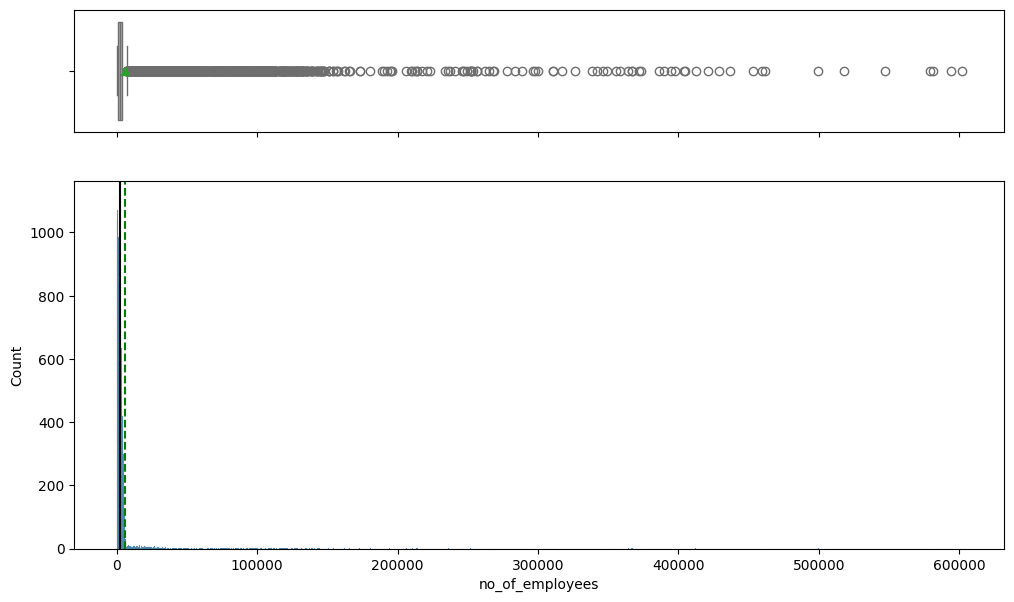

In [40]:
histogram_boxplot(data, "no_of_employees")

- The distribution for number of employees for employers is heavily skewed right

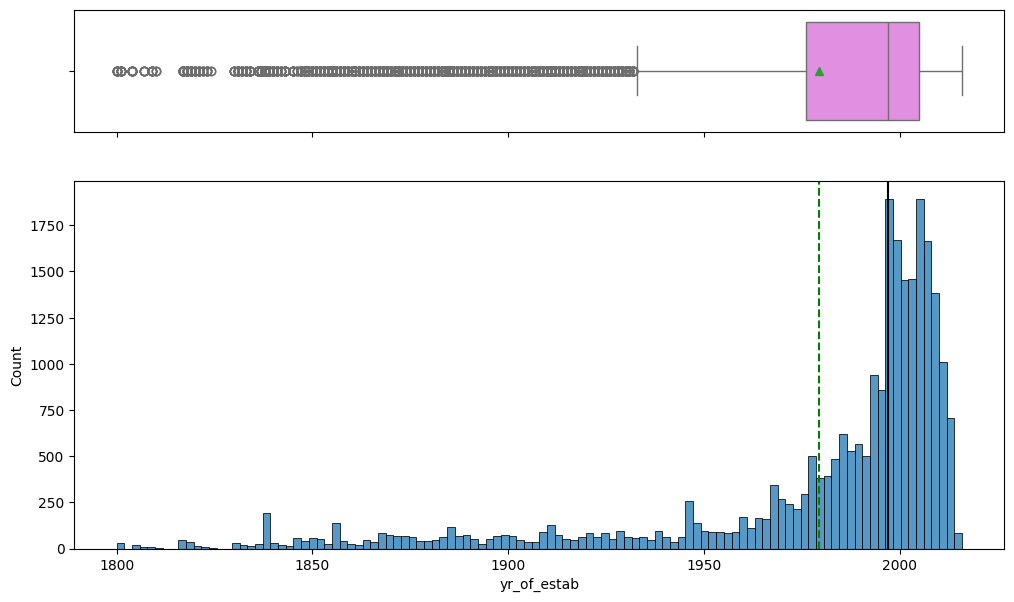

In [41]:
#Observations on year_of_establishment
histogram_boxplot(data, "yr_of_estab")

- The distribution for year established is skewed left

In [42]:
#Observations on prevailing_wage and unit_of_wage

In [43]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

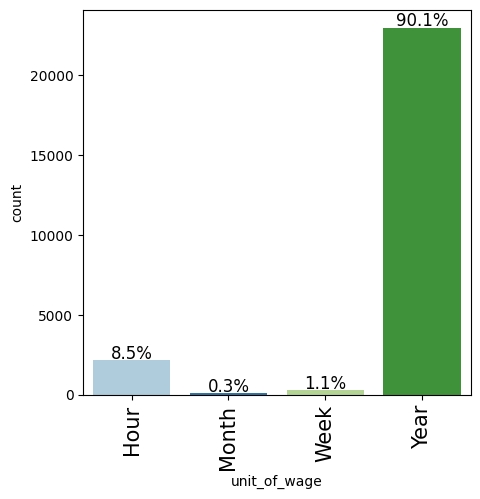

In [44]:
labeled_barplot(data, "unit_of_wage", perc=True);

- Almost 90% of all entries are with unit_of_wage as yearly and only 8.5% entries as hourly. Negligible entries are on a monthly and weekly basis (which requires further investigation)

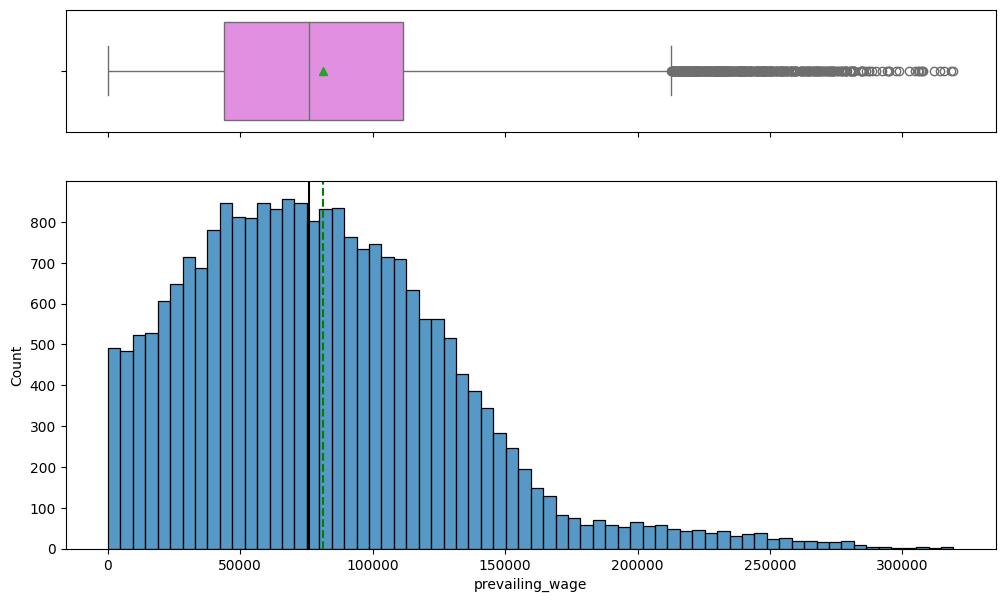

In [45]:
#Observations specifically on data where unit_of_wage is yearly
histogram_boxplot(data[(data["unit_of_wage"]=="Year")], "prevailing_wage")

- The average and median annual salary is approx. USD 70,000 which seems accurate
- The trend appears correct with outliers in the higher income bracket between USD 200,000 to USD 300,000
- There are several very low salaries as well, which appears incorrect and requires further investigation

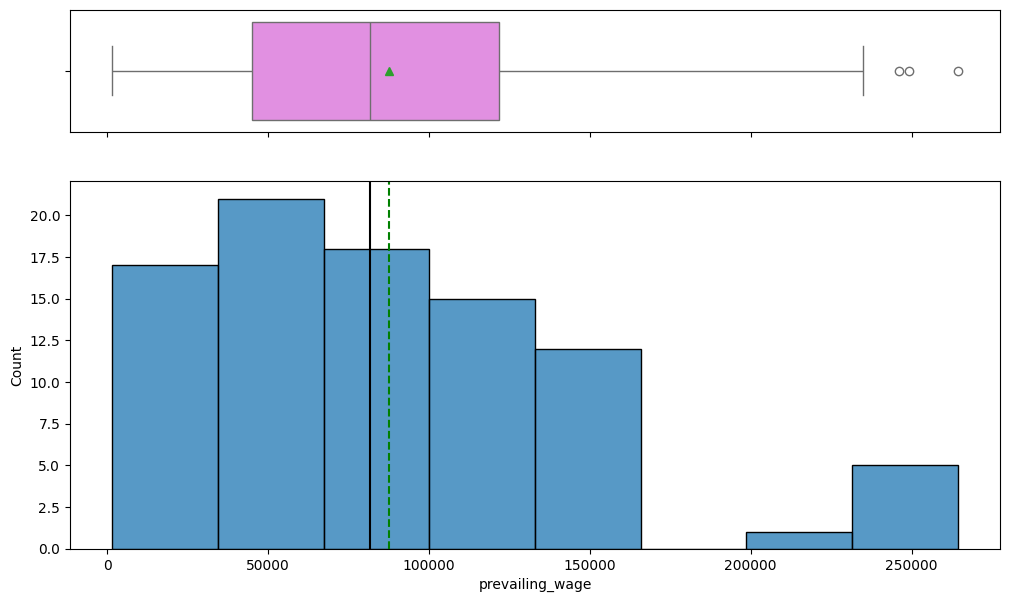

In [46]:
#Observations specifically on data where unit_of_wage is weekly or monthly
histogram_boxplot(data[(data["unit_of_wage"]=="Month")], "prevailing_wage")

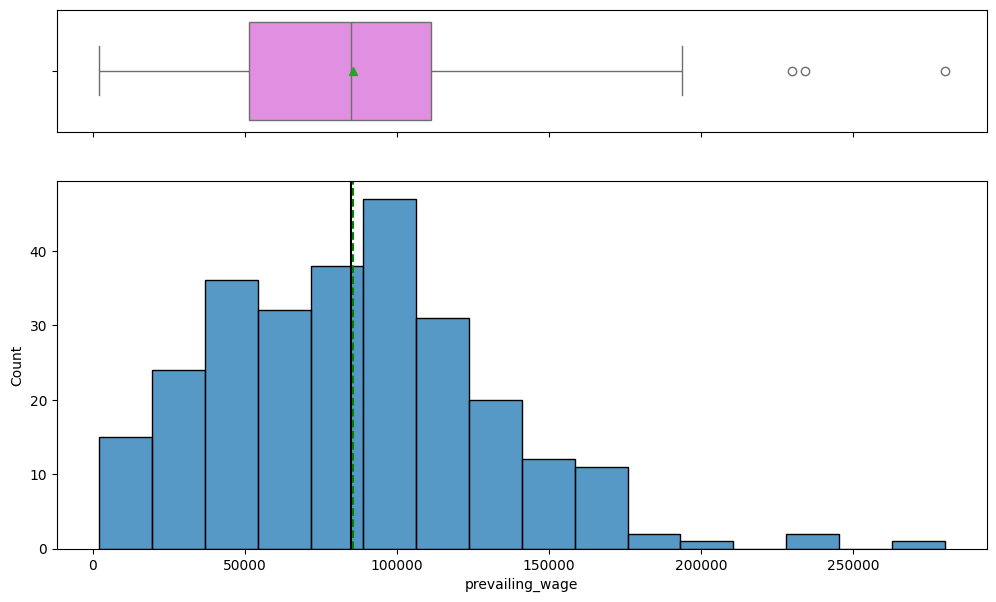

In [47]:
histogram_boxplot(data[(data["unit_of_wage"]=="Week")], "prevailing_wage")

- Based on the data we see above, we can infer that prevailing_wages is likely already a yearly salary where unit_of_wage is either weekly or monthly

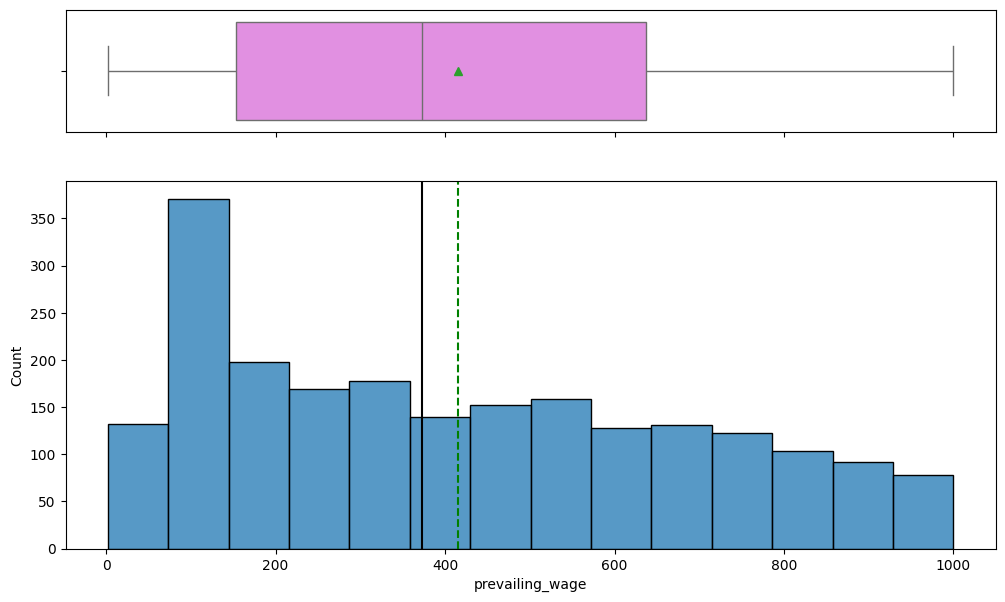

In [48]:
#Observations specifically on data where unit_of_wage is hourly
histogram_boxplot(data[data["unit_of_wage"]=="Hour"], "prevailing_wage")

- Based on the data we see above, we can infer that the prevailing_wage is likely a weekly salary where unit_of_wage is hourly.
(We make this assumption as a median rate of pay of USD 400 per hour appears incorrect.)

#### It can be infered that the dataset is very unclean.
- "prevailing_wages" will be cleaned up to contain only wages on an annual basis, so it is uniform and can be used for model building
- "unit_wages" is assumed to be:
    - Not-Hourly, when the employee is paid a fixed salary (irrespective of the number of hours worked). We will consider any unit_of_wages inherently as weekly, monthly or yearly as Not-Hourly
    - Hourly, when the employee is paid depending on the number of hours worked. We will consider any unit_of_wages inherently as hourly as hourly

In [49]:
data.loc[data["unit_of_wage"]=="Hour", "prevailing_wage"] = \
data.loc[data["unit_of_wage"]=="Hour", "prevailing_wage"]*52
# assuming 52 paid weeks per year

In [50]:
data["unit_of_wage"] = data["unit_of_wage"].astype('object')
data.loc[data["unit_of_wage"]=="Hour", "unit_of_wage"] = "Hourly"
data.loc[data["unit_of_wage"]=="Week", "unit_of_wage"] = "Not_Hourly"
data.loc[data["unit_of_wage"]=="Month", "unit_of_wage"] = "Not_Hourly"
data.loc[data["unit_of_wage"]=="Year", "unit_of_wage"] = "Not_Hourly"
data["unit_of_wage"] = data["unit_of_wage"].astype('category')

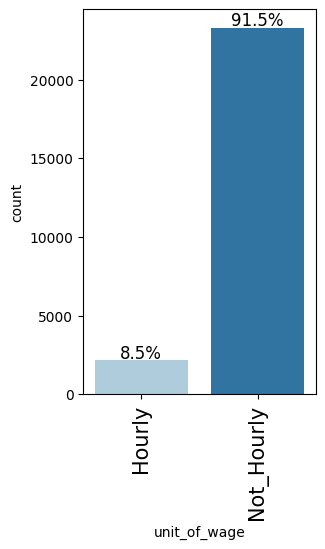

In [51]:
labeled_barplot(data, "unit_of_wage", perc=True)

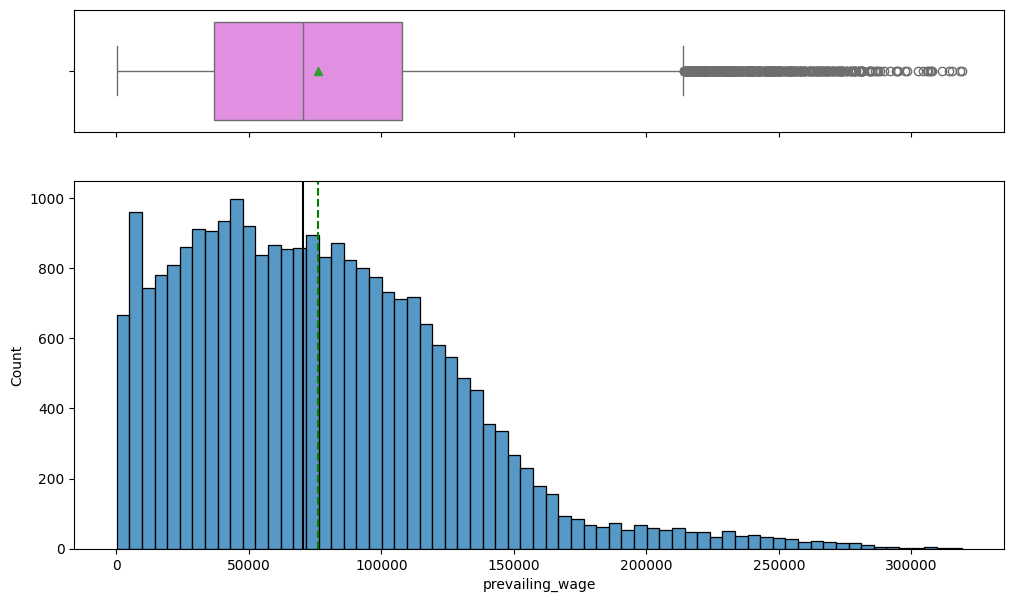

In [52]:
histogram_boxplot(data, "prevailing_wage")

- There are still several lower and upper end outlier in annual_prevailing_wages which requires further investigation

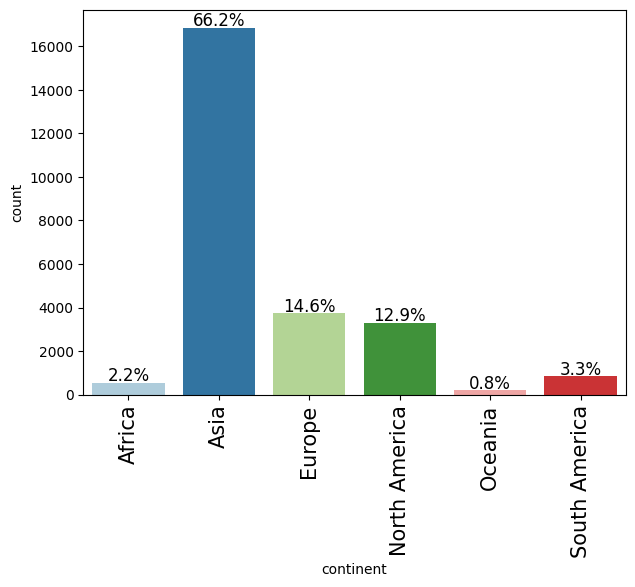

In [53]:
#Observations on continent
labeled_barplot(data, "continent", perc=True)

- Majority of employees (>50%) are from Asia

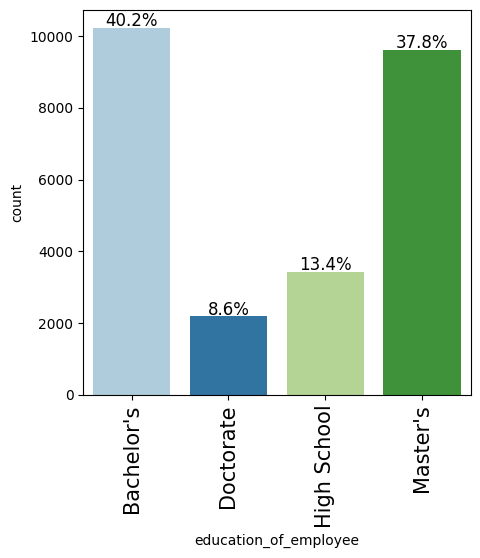

In [54]:
#Observations on education
labeled_barplot(data, "education_of_employee", perc=True)

- Majority of employees have either a bachelor's (40%) or a master's (38%) and minority of applicants have either a doctorate (8%) or only a high school diploma (13%)

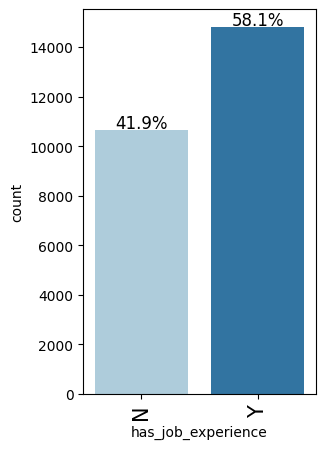

In [55]:
#Observations on job_experience
labeled_barplot(data, "has_job_experience", perc=True)

- Around 58% employees have prior job experience and 42% employees do not

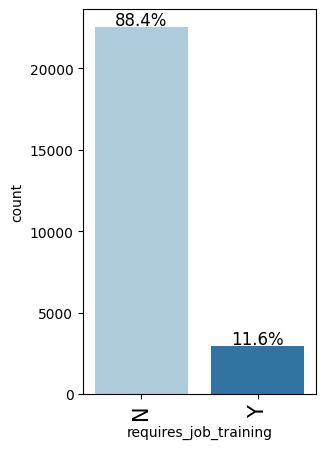

In [56]:
#Observations on requires_training
labeled_barplot(data, "requires_job_training", perc=True)

- Majority do not require job training (88%). Although we observed that only 58% had prior job experience. It is possible that some occupations require employees with no prior job experience

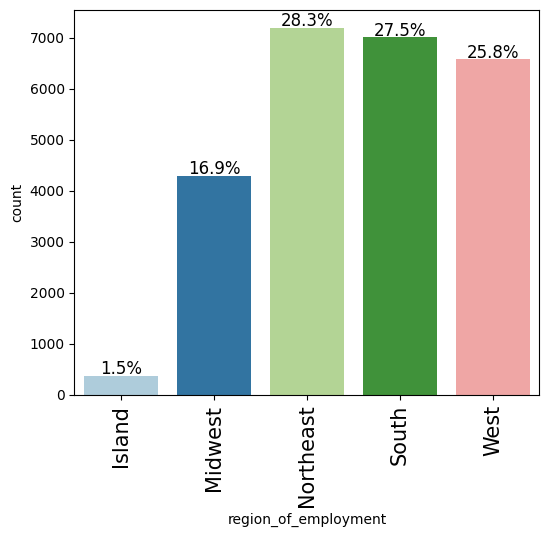

In [57]:
#Observations on region_of_employment
labeled_barplot(data, "region_of_employment", perc=True)

- Northeast, South and West equally have employment opportunities with Human Resource shortages with 25-28% employees applying for visa approval to these regions, followed by Midwest (18%) and Island (1.5%)

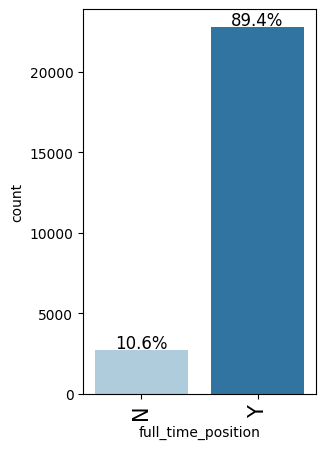

In [58]:
#Observations on full_time_position
labeled_barplot(data, "full_time_position", perc=True)

- 88% are full time positions

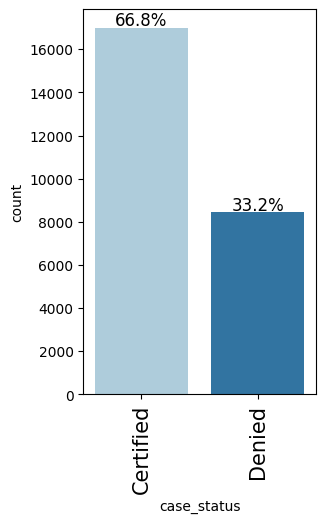

In [59]:
#Observations on case_status
labeled_barplot(data, "case_status", perc=True)

- Approximately, 67% cases are approved and 33% cases are denied

### Bivariate analysis and data preprocessing

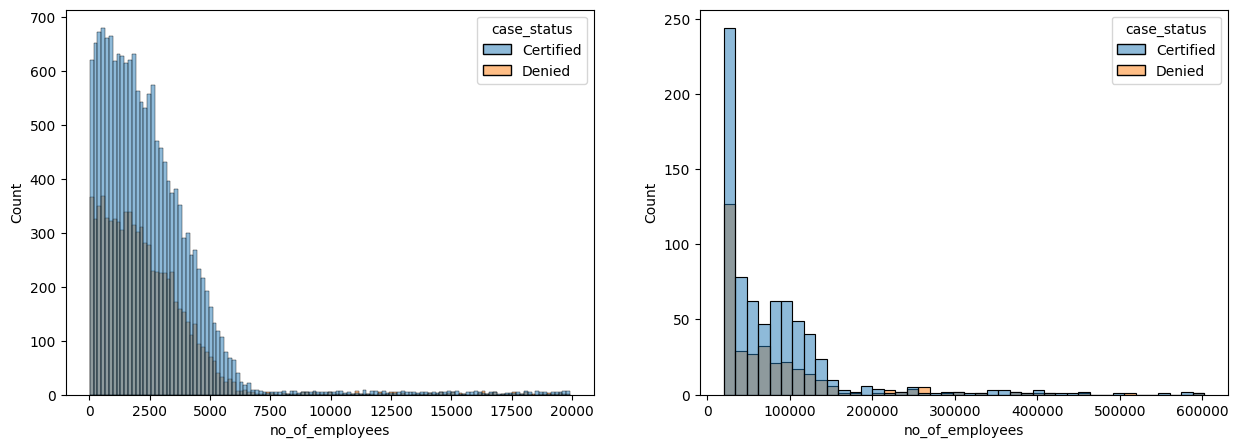

In [60]:
#number of employees and case status
fig,ax=plt.subplots(1,2, figsize=(15,5))
sns.histplot(data=data[data["no_of_employees"]<20000], x="no_of_employees", hue="case_status", ax=ax[0]);
sns.histplot(data=data[data["no_of_employees"]>20000], x="no_of_employees", hue="case_status", ax=ax[1]);

- Greater than twice the number of cases are certified than denied both for employers having lesser as well as more number of employees.
- The large number of outliers in attribute will require further treatment. Although, the ML model is based on decision trees, which optimizes & splits(bins) the data by default, we can choose to bin the continuous datapoints into 3 practically chosen bins to decrease the model building time. This is because from the EDA, we see no spcific relationship between cases being certified and no_of_employees in an organization.  

In [61]:
data["no_of_employees"] = pd.cut( data["no_of_employees"], \
                                  [0, 2500, 7500, np.inf], \
                                  labels = ["Small_Sized(<2500employees)", \
                                            "Medium_Sized(2500-7500employees)", \
                                            "Large_Sized(>75000employees)"])
data["no_of_employees"] = data["no_of_employees"].astype("category")

In [62]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status                       Certified  Denied    All
no_of_employees                                           
All                                   17001    8446  25447
Small_Sized(<2500employees)            9674    5084  14758
Medium_Sized(2500-7500employees)       6272    2874   9146
Large_Sized(>75000employees)           1055     488   1543
------------------------------------------------------------------------------------------------------------------------


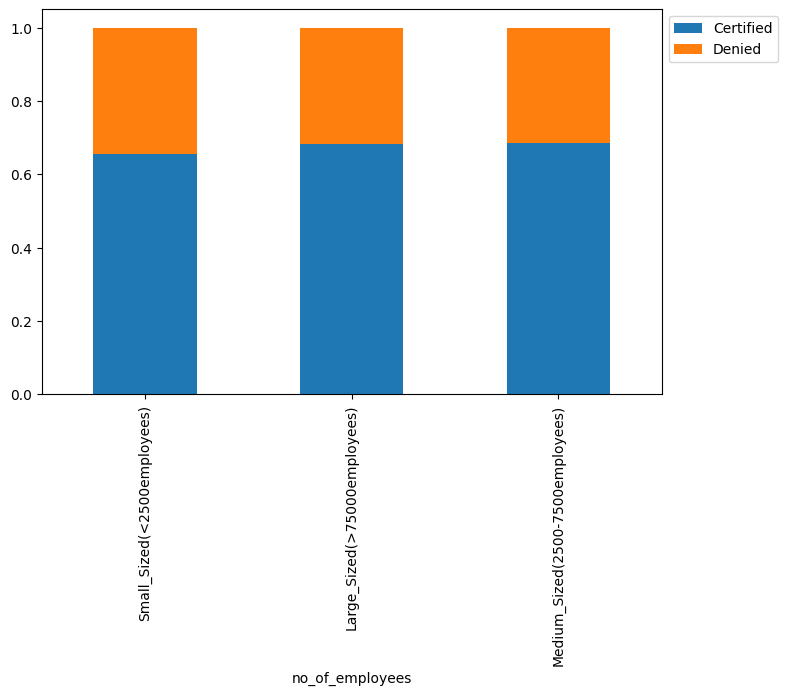

In [63]:

stacked_barplot(data, "no_of_employees", "case_status")

- The information is retained after binning. >65% of cases in all categories are certified
- 58% are small sized companies (less than 2500 employees), 36% are medium_sized and 6% are larege sized companies (more than 7500 employees)

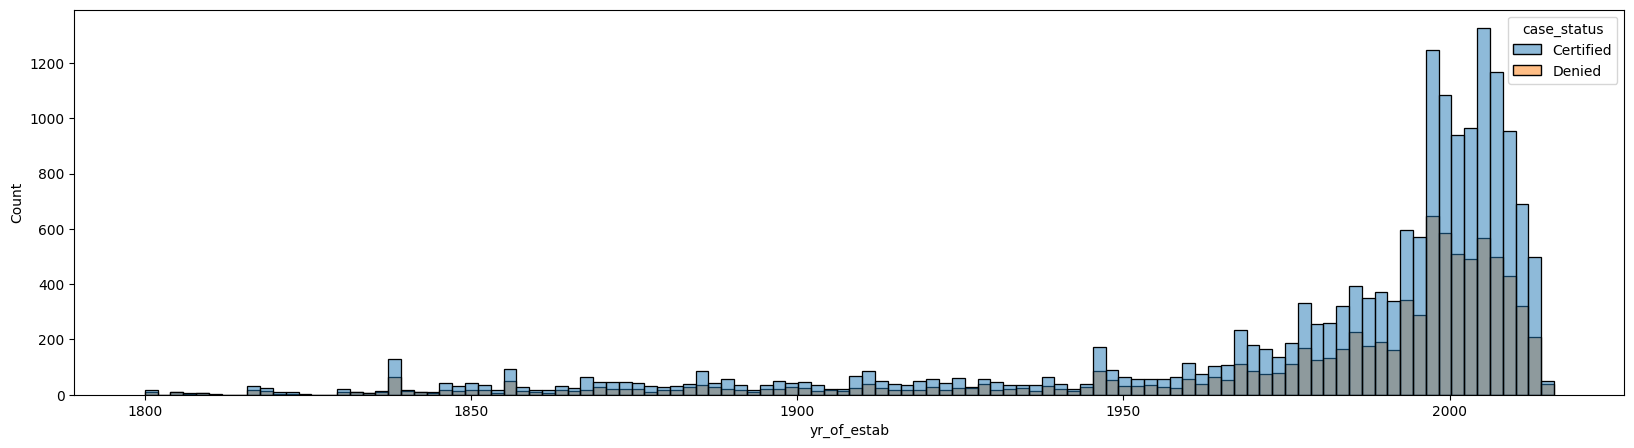

In [64]:
#year of establishment and case_status
plt.figure(figsize=(20,5))
sns.histplot(data, x="yr_of_estab", hue="case_status");

- Similar to before, slightly more than 50% of all cases are certified than denied for employers irrespective of the employer's year of establishment
- There are a large number of lower ended outliers, which will be binned likewise -

In [65]:
data["yr_of_estab"] = pd.cut( data["yr_of_estab"], \
                                  [-np.inf, 1990, np.inf], \
                                  labels = ["Older_Estab(1800-1990)", \
                                            "Newer_Estab(>1990)"])
data["yr_of_estab"] = data["yr_of_estab"].astype("category")

case_status             Certified  Denied    All
yr_of_estab                                     
All                         17001    8446  25447
Newer_Estab(>1990)          10427    5083  15510
Older_Estab(1800-1990)       6574    3363   9937
------------------------------------------------------------------------------------------------------------------------


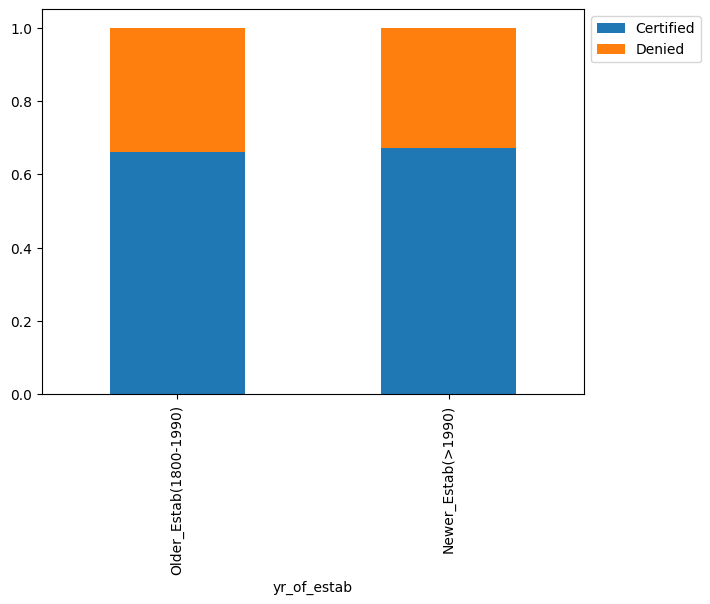

In [66]:
stacked_barplot(data, "yr_of_estab", "case_status")

- The information is retained after binning. >65% of cases in both categories are approved
- Around 61% of employers were established after 1990 and 39% of employers before 1990

case_status   Certified  Denied    All
unit_of_wage                          
All               17001    8446  25447
Not_Hourly        16254    7040  23294
Hourly              747    1406   2153
------------------------------------------------------------------------------------------------------------------------


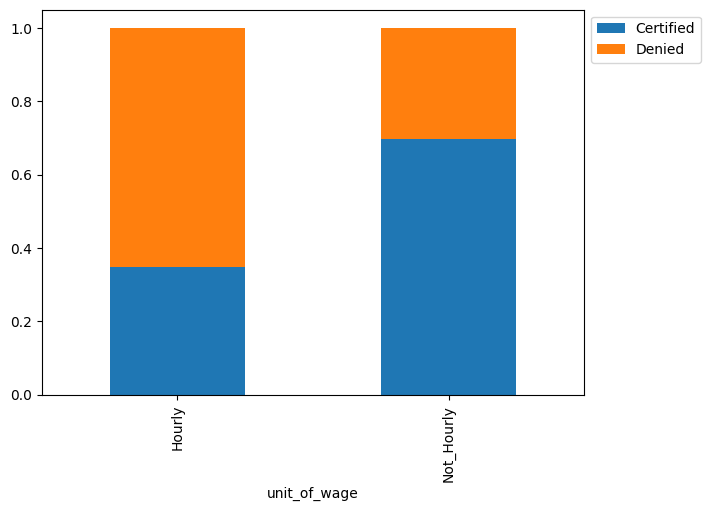

In [67]:
stacked_barplot(data, "unit_of_wage", "case_status")

- Almost 70% of cases are certified when the unit_of_wage is not hourly, and only 35% cases are certified when the unit_of_wage is hourly

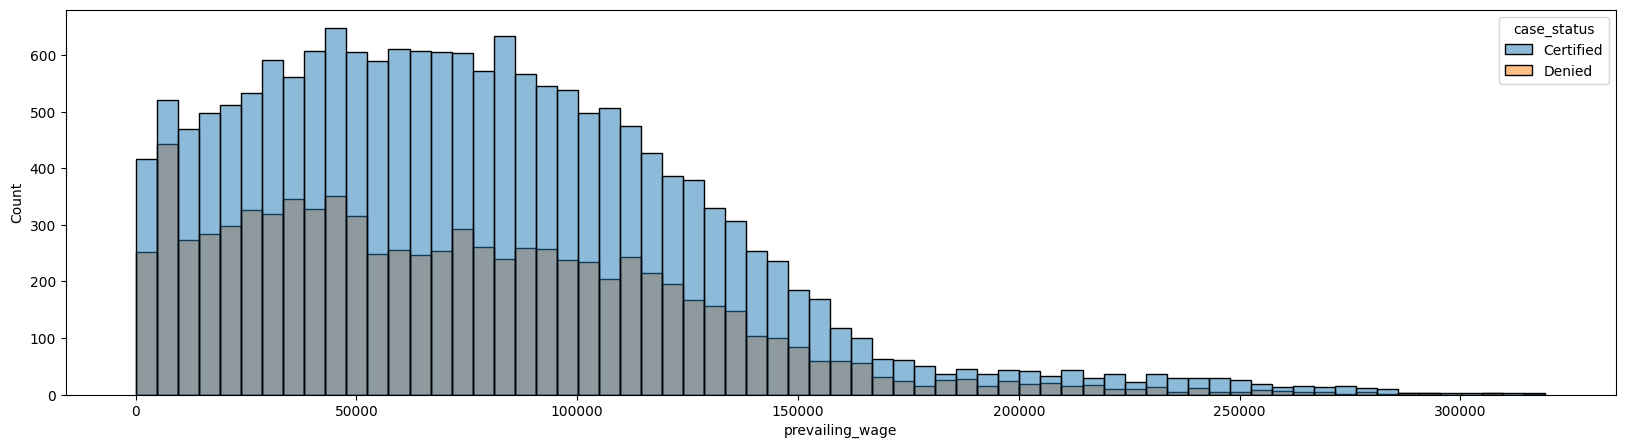

In [68]:
#prevailing_wage and case_status

plt.figure(figsize=(20,5))
sns.histplot(data, x="prevailing_wage", hue="case_status");

- There are some outliers on the lower end (USD 14,500 or less annually) which are worrying. These may reference either positions that are unskilled or where tips received make up portion of the compensation. Similarly, there are outliers on the higher end (USD 200,000 or more annually) which reference highly skilled positions. We see a general trend that ~ twice the cases are certified more than denied.
- % certifications in comparison to % denied drops slightly on the lower end of the prevailing_wage and increases slightly on the upper end of the prevailing_wage
- The number of outliers are not as high as in the previous two instances (no_of_employees & yr_of_estab), as decision trees are immune to outliers, this has not been treated further. As well, above a certain income threshold & below a certain treshold, EDA indicates, similar response for case statuses

case_status    Certified  Denied    All
continent                              
All                17001    8446  25447
Asia               11001    5839  16840
North America       2037    1250   3287
Europe              2953     774   3727
South America        492     359    851
Africa               396     154    550
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


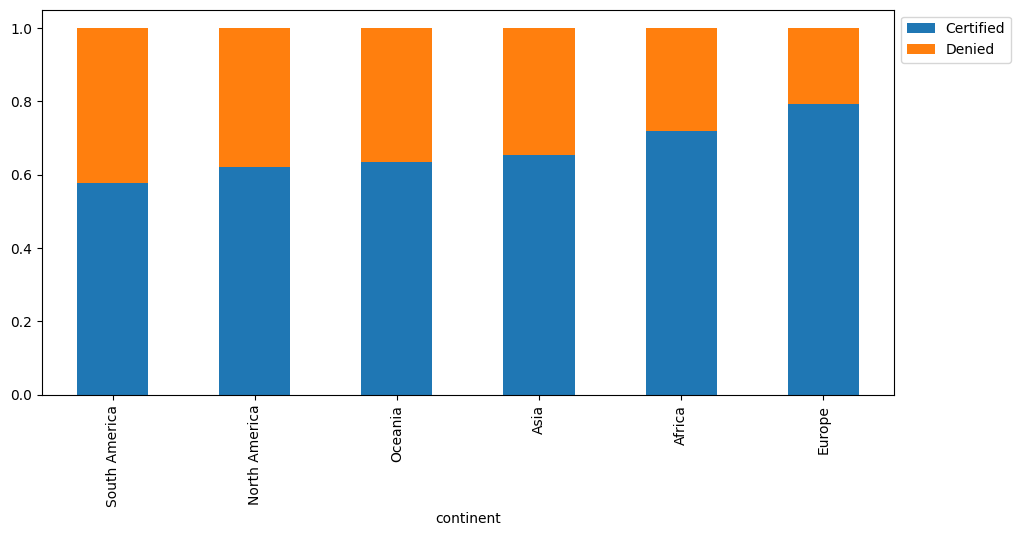

In [69]:
#continent and case status
stacked_barplot(data, "continent", "case_status")

- Irrespective of the continent the employee is from, more cases are certified than denied
- The trend observed w.r.t % certification for continents is Europe > Africa > Asia > Oceania > North America & South America

case_status            Certified  Denied    All
education_of_employee                          
All                        17001    8446  25447
Bachelor's                  6362    3858  10220
High School                 1164    2252   3416
Master's                    7565    2057   9622
Doctorate                   1910     279   2189
------------------------------------------------------------------------------------------------------------------------


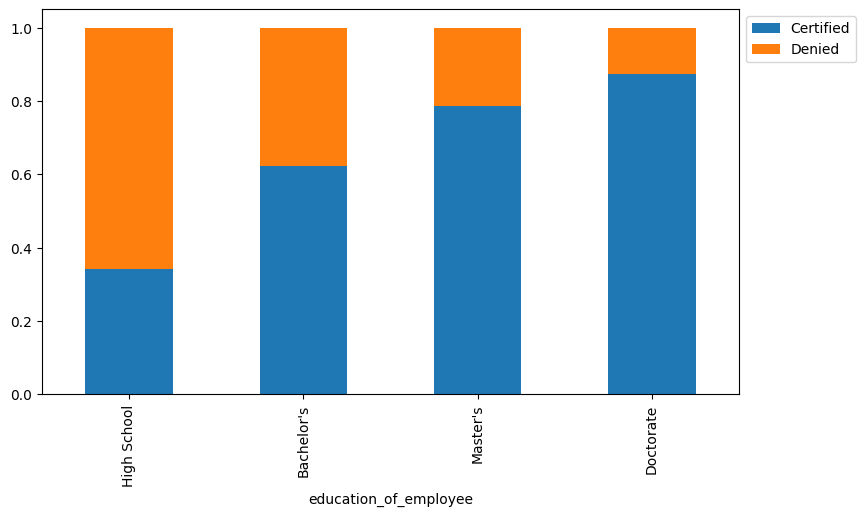

In [70]:
#education and case status
stacked_barplot(data, "education_of_employee", "case_status")

- As expected the, the trend observed w.r.t % visa certification for education of employees is Doctorate > Master's > Bachelor's > High School

case_status         Certified  Denied    All
has_job_experience                          
All                     17001    8446  25447
N                        5986    4675  10661
Y                       11015    3771  14786
------------------------------------------------------------------------------------------------------------------------


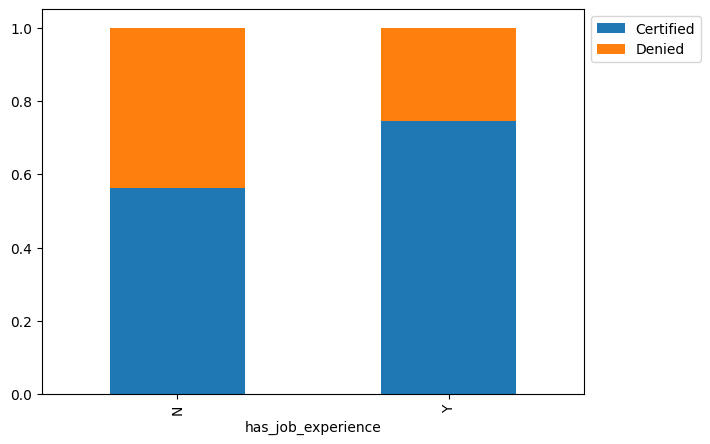

In [71]:
#job_experience and case status
stacked_barplot(data, "has_job_experience", "case_status")

- As expected, the trend observed w.r.t % visa certifications for has_job_experience is Yes > No

case_status            Certified  Denied    All
requires_job_training                          
All                        17001    8446  25447
N                          15000    7498  22498
Y                           2001     948   2949
------------------------------------------------------------------------------------------------------------------------


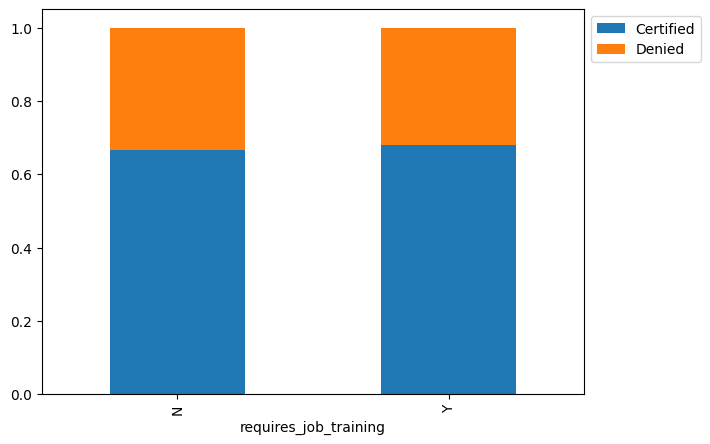

In [72]:
#requires_job_training and case status
stacked_barplot(data, "requires_job_training", "case_status")

Trend observed w.r.t. % visa certifications for requires_job_training is same Yes ~ No

case_status           Certified  Denied    All
region_of_employment                          
All                       17001    8446  25447
Northeast                  4524    2665   7189
West                       4097    2481   6578
South                      4908    2098   7006
Midwest                    3246    1053   4299
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


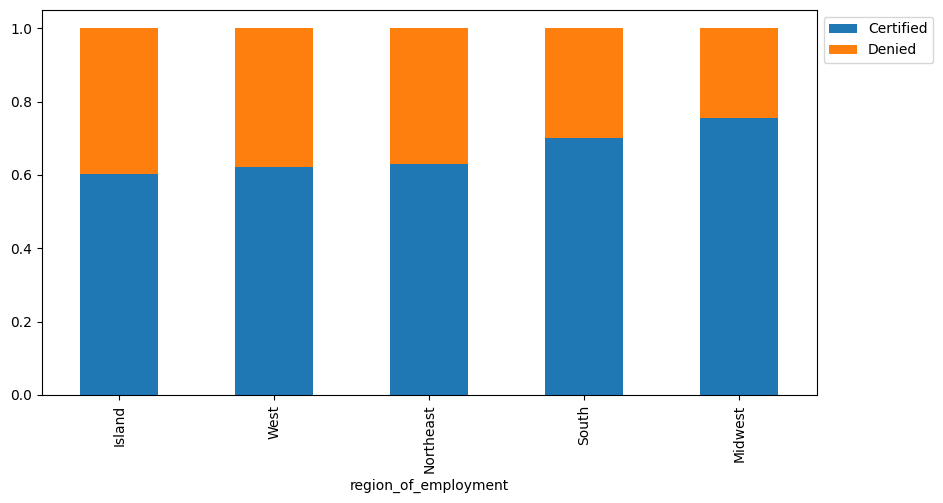

In [73]:
#region_of_employment and case status
stacked_barplot(data, "region_of_employment", "case_status")

- Trend observed w.r.t visa certifications for region_of_employment is MidWest > South > Northeast ~ West > Island

case_status         Certified  Denied    All
full_time_position                          
All                     17001    8446  25447
Y                       15146    7595  22741
N                        1855     851   2706
------------------------------------------------------------------------------------------------------------------------


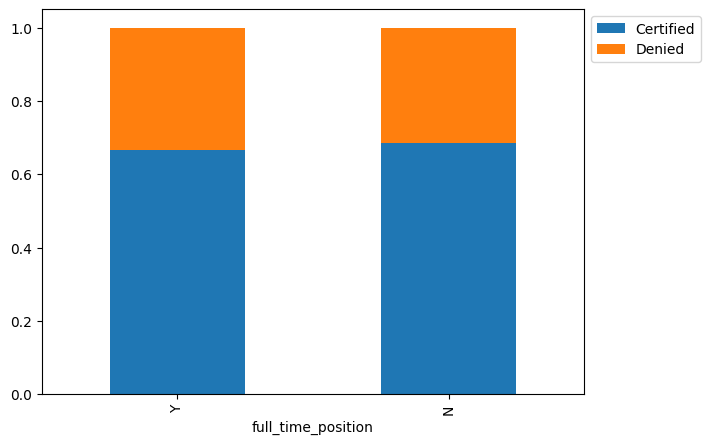

In [74]:
#full_time_position and case status
stacked_barplot(data, "full_time_position", "case_status")

Trend observed w.r.t. % visa certifications for full_time_position is same Yes ~ No

### EDA Sumamrized

- More than twice the number of cases were certified than denied irrespective of the number of employees in the employer's organization & the year of establishment of the employer's organization. These attributes are hence, not thought to have an impact on case statuses
   - Both these attrtibutes are heavily skewed, the no_of_employees is skewed right but yr_of_estab is skewed left
   - From the EDA, we infer 58% of all cases were for smaller organizations (<2500 employees) and 61% of all cases were for employer's established after 1990
  
  
- Only 35% of the cases were certified when the unit_of_wage is Hour-ly but 70% were certified when the unit_of_wage are not Hour-ly (i.e, Week-ly, Month-ly or Year-ly). This indicates unit_of_wage is an important attribute that can influence case statuses
  - From the EDA, we infer only 8.5% of all cases were for unit_of_wage Hour-ly and the remaining 91.5% of all cases were for unit_of_wage not Hour-ly (i.e, Week-ly, Month-ly or Year-ly)
    
    
- Majority of cases are from applicants in Asia (66%), then Europe (15%), N.America (13%) & S.America (3%); however, cases getting certified is highest for Europe (80% of such cases), then Africa (72% of such cases), then Asia (65% of such cases), .. & least for S.America & N.America (around 60% of such cases). More cases are certified than denied irrespective of the continent. Being from Europe is though to be an important attribute to have an impact on case statuses


- Majority of applicants have a bachelor's (40%) or a master's degree (37.87%). A small number have only high school certification (13.4%) or are very highly educated/ doctorate (8.6%). However, cases getting certified is highest for doctorate degree (>86%),followed by master degree (>76%), then bachelor's (~62%). The cases getting certified is very low for those applicants with only a high school certification (<35%). The trend observed is intuitive and one can expect attributes having a doctorate degress & having only a high school certification to significantly contribute to a case being certified and denied respectively


- From the EDA, we infer that 58% of all applicants have prior job experience and 42% do not. The cases getting certified is high for applicants with prior job experience (75% of such cases) and low for applicants without prior job experience (~56% of such cases). This is again an important attribute with an applicant having prior job experience significantly contributing to a case being certified


- Majority do not require the employee to receive any additional job training. This attribute was not found to have an impact on the case statuses


- Majority of the applications are to Northeast (28.3%), then South (27.5%), then West (25.8%), Midwest (16.9%) and least to Island (1.5%) regions of the US. However, the cases certified follows the trend Midwest (75% of such cases), then South (70% of such cases), then Northeast, West, & Island (60% of such cases). Region of employment being Midwest hence is an important attribute contributing positively to a case being certified


- Majority of the jobs are full time rather than part time. This attribute was not found to have an impact on the case statuses

## Data Preprocessing

- Preparing data for modeling
- Splitting the data

In [75]:
df.head(10)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_size,company_age
0,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,4000+,0-10
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,2000-3000,10-20
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,4000+,0-10
3,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,0-1000,50+
4,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,1000-2000,10-20
5,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified,2000-3000,0-10
6,Asia,Bachelor's,N,N,4985,1994,South,53635.39,Year,Y,Certified,4000+,20-30
7,North America,Bachelor's,Y,N,3035,1924,West,418.23,Hour,Y,Denied,3000-4000,50+
8,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.19,Year,Y,Certified,4000+,0-10
9,Europe,Doctorate,Y,N,2251,1995,South,67514.76,Year,Y,Certified,2000-3000,20-30


In [76]:
#drop the int_64 columns from the dataframe, since this information is captured through the features engineered above
df_model = df.drop(labels=['no_of_employees','yr_of_estab'], axis=1, inplace=True)

#### Encoding Certified as 1 and Denied as 0, as the OFLC wants to identify those visa applicants who are predicted to be approved.

In [77]:
df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

### Spliting the data
We will use 70% of data for training and 30% for testing.

In [78]:
#create a dataframe of the predictor feature columns
X = df.drop('case_status',axis=1)
#create a datafrane of the predicted class (1=True, 0=False)
Y = df['case_status']

#generate dummy variables for each categorical variable
X = pd.get_dummies(X, drop_first=True)

#split the data into train and test datasets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [79]:
#confirm the split
print("{0:0.2f}% data is in training set".format((len(x_train)/len(df.index)) * 100))
print("{0:0.2f}% data is in test set".format((len(x_test)/len(df.index)) * 100))

70.00% data is in training set
30.00% data is in test set


In [80]:
#confirm the shape of both data sets and the ratio of classes is the same across both train and test datasets
print("Shape of Training set : ", x_train.shape)
print("Shape of test set : ", x_test.shape)
print(' ')
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print(' ')
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17812, 27)
Shape of test set :  (7635, 27)
 
Percentage of classes in training set:
case_status
1   0.67
0   0.33
Name: proportion, dtype: float64
 
Percentage of classes in test set:
case_status
1   0.67
0   0.33
Name: proportion, dtype: float64


In [81]:
from sklearn.tree import DecisionTreeClassifier

dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

## Scoring our Decision Tree

In [82]:
print(dTree.score(x_train, y_train))
print(dTree.score(x_test, y_test))

1.0
0.6453176162409954


## Bagging and Boosting models

### Model evaluation criterion

#### Model can make wrong predictions as:
1. Predicting an applicant should be approved the applicant is denied.
2. Predicting an applicant should be denied and the applicant is approved.

#### Which case is more important?
* Both are important:
    * If an applicant is approved when they would have been denied, an unqualified employee will get a job that should have been filled by a US citizen.
    * If an applicant is denied when they should have been approved, U.S. companies will not be able to fill critical positions and the overall economy will not be as productive.

#### How to reduce the losses?
* As the process of reviewing each application is time and resource-intensive, this model should identify those candidates predicted to be approved, so agents can prioritize these applications.
* F1 Score can be used a the metric for evaluation of the model, as the greater the F1 score, the higher the chances of minimizing False Negatives and False Positives.
* We will use balanced class weights, where applicable, so that model focuses equally on both classes.


#### Defining functions to provide metric scores (i.e., accuracy, recall, and precision) on the train and test datasets and to show the resulting confusion matrices.

In [83]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [84]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree Model

* We will build our model using the DecisionTreeClassifier function, using default 'gini' criteria to split.

In [85]:
dtree = DecisionTreeClassifier(criterion='gini', random_state=1, class_weight='balanced')

In [86]:
dtree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

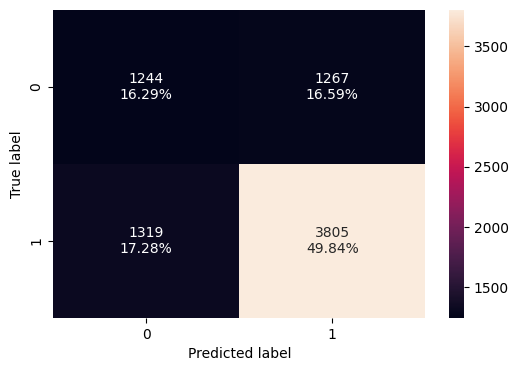

In [87]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(dtree, x_test, y_test)

**Confusion Matrix -**

* Applicant was approved and the model predicted approval :  True Positive (observed=1,predicted=1)

* Applicant was denied and the model predicted approval : False Positive (observed=0,predicted=1)

* Applicant was denied and the model predicted denial : True Negative (observed=0,predicted=0)

* Applicant was approved and the model predicted denial : False Negative (observed=1,predicted=0)

In [88]:
dtree_model_train_perf=model_performance_classification_sklearn(dtree, x_train, y_train)
print("Training performance \n",dtree_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00


In [89]:
dtree_model_test_perf=model_performance_classification_sklearn(dtree, x_test, y_test)
print("Testing performance \n",dtree_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.66    0.74       0.75 0.75


* The Decision Tree is working well on the training data, but is not able to generalize well on the test data, indicating the model is overfit.

### Bagging Classifier

In [90]:
bagging = BaggingClassifier(random_state=1)
bagging.fit(x_train,y_train)

BaggingClassifier(random_state=1)

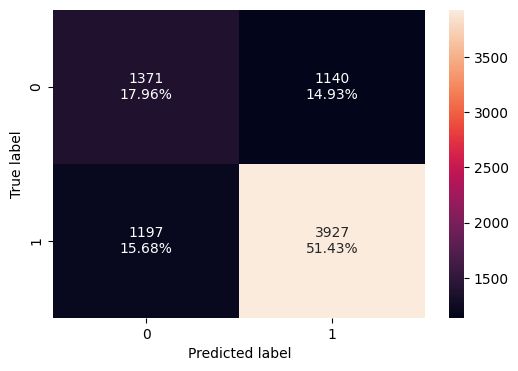

In [91]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(bagging, x_test, y_test)

In [92]:
bagging_model_train_perf=model_performance_classification_sklearn(bagging, x_train, y_train)
print("Training performance \n",bagging_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.98    0.98       0.99 0.99


In [93]:
bagging_model_test_perf=model_performance_classification_sklearn(bagging, x_test, y_test)
print("Testing performance \n",bagging_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.69    0.77       0.78 0.77


* Similar to the Decision Tree model, this bagging classifer is overfit to the training dataset but has a higher F1 score.

### Random Forest

In [94]:
rf = RandomForestClassifier(random_state=1)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=1)

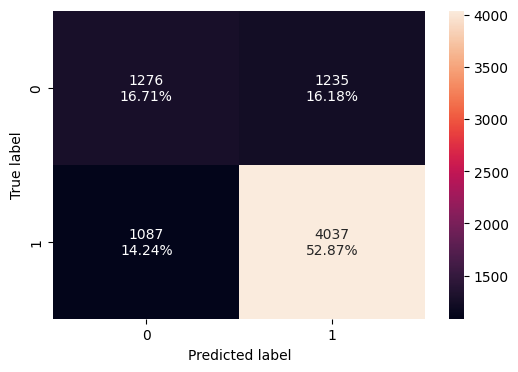

In [95]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(rf,x_test,y_test)

In [96]:
rf_model_train_perf=model_performance_classification_sklearn(rf,x_train,y_train)
print("Training performance \n",rf_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00


In [97]:
rf_model_test_perf=model_performance_classification_sklearn(rf,x_test,y_test)
print("Testing performance \n",rf_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.70    0.79       0.77 0.78


* Similar to the models above, this Random Forest is also overfit to the training dataset but has the highest F1 score so far.

### AdaBoost Classifier

In [98]:
ab_classifier=AdaBoostClassifier(random_state=1)
ab_classifier.fit(x_train,y_train)

AdaBoostClassifier(random_state=1)

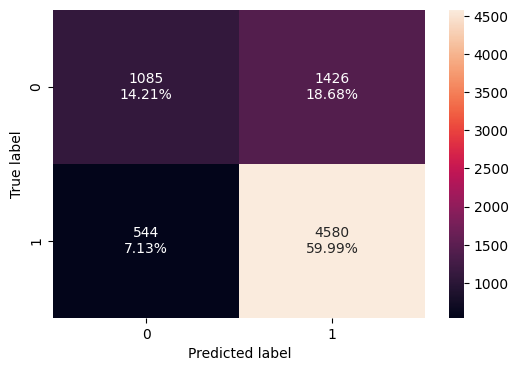

In [99]:

#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(ab_classifier, x_test,y_test)

In [100]:
ab_classifier_model_train_perf = model_performance_classification_sklearn(ab_classifier,x_train,y_train)
print("Training performance \n",ab_classifier_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.88       0.76 0.82


In [101]:
ab_classifier_model_test_perf = model_performance_classification_sklearn(ab_classifier,x_test,y_test)
print("Testing performance \n",ab_classifier_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.74    0.89       0.76 0.82


* This AdaBoost classifer performs equally well on the training and testing datasets, indicating that the model is not overfit.
* Additionally, the model performs the best of any model yet (i.e., highest F1 score) on the testing data.

### Gradient Boosting Classifier

In [102]:
gbc = GradientBoostingClassifier(random_state=1)
gbc.fit(x_train,y_train)

GradientBoostingClassifier(random_state=1)

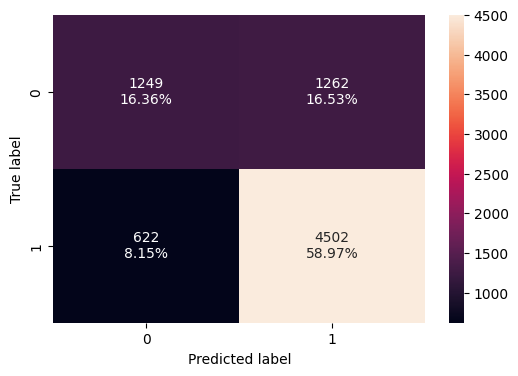

In [103]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(gbc, x_test,y_test)

In [104]:
gbc_classifier_model_train_perf = model_performance_classification_sklearn(gbc,x_train,y_train)
print("Training performance \n",gbc_classifier_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.87       0.78 0.83


In [105]:
gbc_classifier_model_test_perf = model_performance_classification_sklearn(gbc,x_test,y_test)
print("Training performance \n",gbc_classifier_model_test_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.88       0.78 0.83


* This Gradient Boosting classifer performs equally well on the training and testing datasets, indicating that the model is not overfit.
* Additionally, this model performs even better than the AdaBoost model above.

### Base models comparison

In [106]:
# create a dataframe comparing the performance of the base models on the training data

models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T,
     bagging_model_train_perf.T,
     rf_model_train_perf.T,
     ab_classifier_model_train_perf.T,
     gbc_classifier_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Random Forest",
    "AdaBoost Classifier",
    "Gradient Boosting Classifier"]
print("Training performance comparison of base models:")
models_train_comp_df

Training performance comparison of base models:


,Decision Tree,Bagging Classifier,Random Forest,AdaBoost Classifier,Gradient Boosting Classifier
Accuracy,1.00,0.98,1.00,0.73,0.75
Recall,1.00,0.98,1.00,0.88,0.87
Precision,1.00,0.99,1.00,0.76,0.78
F1,1.00,0.99,1.00,0.82,0.83


In [107]:
# create a dataframe comparing the performance of the base models on the testing data

models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T,
     bagging_model_test_perf.T,
     rf_model_test_perf.T,
     ab_classifier_model_test_perf.T,
     gbc_classifier_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Random Forest",
    "AdaBoost Classifier",
    "Gradient Boosting Classifier"]
print("Testing performance comparison of base models:")
models_test_comp_df

Testing performance comparison of base models:


,Decision Tree,Bagging Classifier,Random Forest,AdaBoost Classifier,Gradient Boosting Classifier
Accuracy,0.66,0.69,0.70,0.74,0.75
Recall,0.74,0.77,0.79,0.89,0.88
Precision,0.75,0.78,0.77,0.76,0.78
F1,0.75,0.77,0.78,0.82,0.83


* Overall, the bagging models perform best on the training data, due to all three of the models overfitting this data set.
* As shown above, all three of the boosting models do not overfit the data and achieve higher F1 scores on the training data set, with the Gradient Boosting classifier performing the best.

##  Hyperparameter tuning

**Tuning Decision Tree**

In [108]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(5,30,5),
              'min_samples_leaf': [3, 5, 7],
              'max_leaf_nodes' : [2, 4, 6],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=4,
                       min_impurity_decrease=0.0001, min_samples_leaf=3,
                       random_state=1)

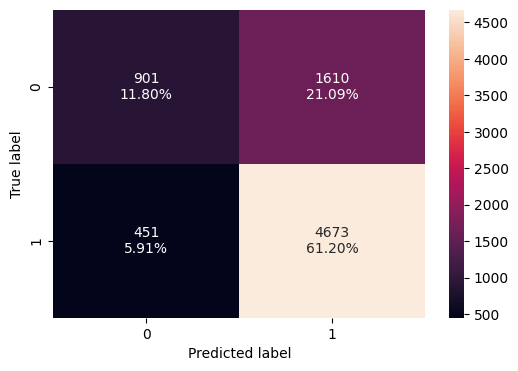

In [109]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(dtree_estimator, x_test,y_test)

In [110]:
dtree_estimator_model_train_perf=model_performance_classification_sklearn(dtree_estimator, x_train,y_train)
print("Training performance \n",dtree_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


In [111]:
dtree_estimator_model_test_perf=model_performance_classification_sklearn(dtree_estimator, x_test, y_test)
print("Testing performance \n",dtree_estimator_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


* The Decision Tree model after tuning performs equally well on the training and testing datasets, indicating that the model is not overfit.
* Additionally, this model performs as well as two out of the three boosting models above on the test data.
* Both of these indicate this tuned model is a significant improvements over the base model.

**Tuning Bagging Classifier**

Hyperparameters available for bagging classifier include:
   - base_estimator: The base estimator to fit on random subsets of the dataset. If None(default), then the base estimator is a decision tree.
   - n_estimators: The number of trees in the forest, default = 100.
   - max_features: The number of features to consider when looking for the best split.
   - bootstrap: Whether bootstrap samples are used when building trees. If False, the entire dataset is used to build each tree, default=True.
   - bootstrap_features: If it is true, then features are drawn with replacement. Default value is False.
   - max_samples: If bootstrap is True, then the number of samples to draw from X to train each base estimator. If None (default), then draw N samples, where N is the number of observations in the train data.
   - oob_score: Whether to use out-of-bag samples to estimate the generalization accuracy, default=False.

In [112]:
# random search for bagging classifier
parameters = {'max_samples': [0.7,0.8,0.9,1],
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : np.arange(50, 100, 10)
             }

#run the randomized search
rand_bag = RandomizedSearchCV(BaggingClassifier(random_state=1,bootstrap=True),
                              parameters, scoring = 'f1', cv = 5, random_state=1)
rand_bag = rand_bag.fit(x_train, y_train)

# Set the clf to the best combination of parameters
bag_tuned = rand_bag.best_estimator_

# Fit the best algorithm to the data
bag_tuned.fit(x_train, y_train)

BaggingClassifier(max_features=0.8, max_samples=0.8, n_estimators=70,
                  random_state=1)

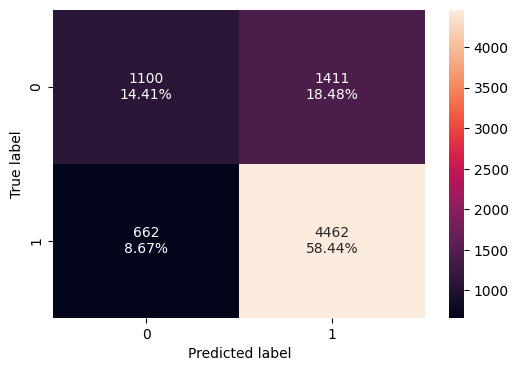

In [113]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(bag_tuned, x_test,y_test)

In [114]:
bagging_estimator_model_train_perf=model_performance_classification_sklearn(bag_tuned, x_train,y_train)
print("Training performance \n",bagging_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.99    1.00       0.99 0.99


In [115]:
bagging_estimator_model_test_perf=model_performance_classification_sklearn(bag_tuned, x_test, y_test)
print("Testing performance \n",bagging_estimator_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.87       0.76 0.81


* The Bagging Classifier after tuning performs far less well on the test data than on the training data, indicating that the model is still overfit.
* However, this model does perform better than the base model.

**Tuning Random Forest**

Hyperparameters for Random Forest include:

- n_estimators: The number of trees in the forest, default = 100.
- max_features: The number of features to consider when looking for the best split.
- class_weight: Weights associated with classes in the form {class_label: weight}.If not given, all classes are supposed to have weight one.  
- For example: If the frequency of class 0 is 80% and the frequency of class 1 is 20% in the data, then class 0 will become the dominant class and the model will become biased toward the dominant classes. In this case, we can pass a dictionary {0:0.2,1:0.8} to the model to specify the weight of each class and the random forest will give more weightage to class 1.
- bootstrap: Whether bootstrap samples are used when building trees. If False, the entire dataset is used to build each tree, default=True.
- max_samples: If bootstrap is True, then the number of samples to draw from X to train each base estimator. If None (default), then draw N samples, where N is the number of observations in the train data.
- oob_score: Whether to use out-of-bag samples to estimate the generalization accuracy, default=False.

- Note: A lot of hyperparameters of Decision Trees are also available to tune  Random Forest like max_depth, min_sample_split etc.


In [116]:
# Choose the type of classifier.
rf_estimator = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {"n_estimators": np.arange(10, 40, 10),
              "min_samples_leaf": np.arange(5, 10),
              "min_samples_split": [3, 5, 7],
              "max_features": ["sqrt", "log2"],
              "max_samples": np.arange(0.3, 0.7, 0.1),
}

# Run the randomized search
rand_rf = RandomizedSearchCV(rf_estimator, parameters, scoring='f1', cv=5, n_jobs=-1, random_state=1)
rand_rf = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator = rand_rf.best_estimator_

# Fit the best algorithm to the data.
rf_estimator.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=4,
                       min_impurity_decrease=0.0001, min_samples_leaf=3,
                       random_state=1)

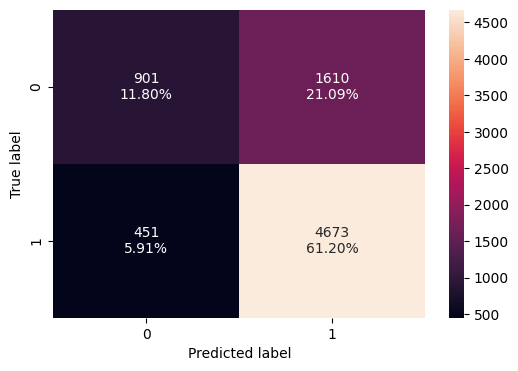

In [117]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(rf_estimator, x_test,y_test)

In [118]:
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator, x_train,y_train)
print("Training performance \n",rf_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


In [ ]:
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator, x_test, y_test)
print("Testing performance \n",rf_estimator_model_test_perf)

* The Random Forest after tuning performs equally well on the training and testing datasets, indicating that the model is not overfit.
* Additionally, this model performs as well as two out of the three boosting models and the tuned Decision Tree on the test data.
* Both of these indicate this tuned model is a significant improvements over the base model.

#### Tuning AdaBoost Classifier

Hyperparameters include:
   - base_estimator: The base estimator from which the boosted ensemble is built. By default the base estimator is a decision tree with max_depth=1
   - n_estimators: The maximum number of estimators at which boosting is terminated. Default value is 50.
   - learning_rate: Learning rate shrinks the contribution of each classifier by learning_rate. There is a trade-off between learning_rate and n_estimators.

In [120]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    #Let's try different max_depth for base_estimator
    "base_estimator":[DecisionTreeClassifier(max_depth=1, random_state=1, class_weight='balanced'),
                      DecisionTreeClassifier(max_depth=2, random_state=1, class_weight='balanced'),
                      DecisionTreeClassifier(max_depth=3, random_state=1, class_weight='balanced')],
    "n_estimators": np.arange(10,110,10),
    "learning_rate":np.arange(0.1,2,0.1)
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search
rand_abc = RandomizedSearchCV(abc_tuned, parameters, scoring=acc_scorer,cv=5, n_jobs=-1, random_state=1)
rand_abc = rand_abc.fit(x_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = rand_abc.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(x_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(class_weight='balanced',
                                                         max_depth=1,
                                                         random_state=1),
                   learning_rate=0.5, n_estimators=20, random_state=1)

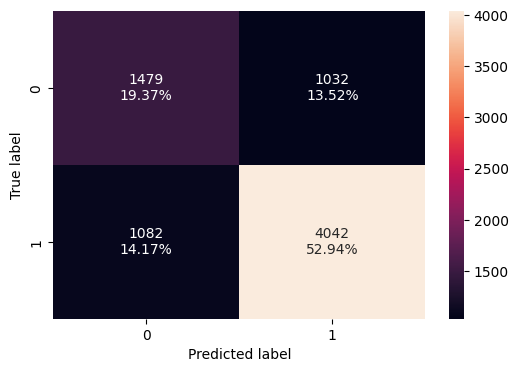

In [121]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(abc_tuned, x_test,y_test)

In [122]:
abc_tuned_model_train_perf=model_performance_classification_sklearn(abc_tuned, x_train,y_train)
print("Training performance \n",abc_tuned_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.78       0.79 0.79


In [123]:
abc_tuned_model_test_perf=model_performance_classification_sklearn(abc_tuned, x_test, y_test)
print("Testing performance \n",abc_tuned_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.79       0.80 0.79


* The AdaBoost classifier after tuning performs equally well on the training and testing datasets, indicating that the model is not overfit.
* However, this model performs worse than the base model on both the train and test data.

#### Tuning GradientBoost Classifier

Most of the hyperparameters available match those of a random forest classifier.
  - init: An estimator object that is used to compute the initial predictions. If ‘zero’, the initial raw predictions are set to zero. By default, a DummyEstimator predicting the classes priors is used.
  - There is no class_weights parameter in gradient boosting.

In [124]:
# Choose the type of classifier.
gb_tuned = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {"n_estimators": [150,200,250,300],
              "subsample":[0.8,0.9,1],
              "max_features":[0.7,0.8,0.9,1],
              "learning_rate": np.arange(0.1, 0.4, 0.1)}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search
rand_gb = RandomizedSearchCV(gb_tuned, parameters, scoring=scorer,cv=5, n_jobs=-1, random_state=1)
rand_gb = rand_gb.fit(x_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = rand_gb.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(x_train, y_train)

GradientBoostingClassifier(max_features=0.7, n_estimators=300, random_state=1,
                           subsample=1)

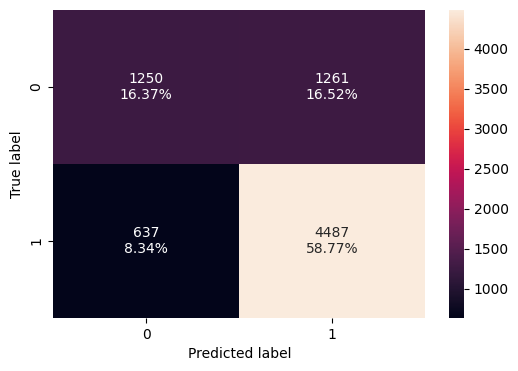

In [125]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(gb_tuned, x_test,y_test)

In [126]:
gb_tuned_model_train_perf=model_performance_classification_sklearn(rf_estimator, x_train,y_train)
print("Training performance \n",gb_tuned_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


In [127]:
gb_tuned_model_test_perf=model_performance_classification_sklearn(rf_estimator, x_test, y_test)
print("Testing performance \n",gb_tuned_model_test_perf)

Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


* The Gradient Boosting classifier after tuning performs equally well on the training and testing datasets, indicating that the model is not overfit.
* However, this model performs slightly worse than the base model on both the train and test data.

### Tuned models comparison

In [128]:
# create a dataframe comparing the performance of the tuned models on the training data

tuned_models_train_comp_df = pd.concat(
    [dtree_estimator_model_train_perf.T,
     bagging_estimator_model_train_perf.T,
     rf_estimator_model_train_perf.T,
     abc_tuned_model_train_perf.T,
     gb_tuned_model_train_perf.T],
    axis=1,
)
tuned_models_train_comp_df.columns = [
    "Tuned Decision Tree",
    "Tuned Bagging Classifier",
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boosting Classifier"]
print("Training performance comparison of tuned models:")
tuned_models_train_comp_df

Training performance comparison of tuned models:


,Tuned Decision Tree,Tuned Bagging Classifier,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boosting Classifier
Accuracy,0.73,0.99,0.73,0.72,0.73
Recall,0.91,1.00,0.91,0.78,0.91
Precision,0.74,0.99,0.74,0.79,0.74
F1,0.82,0.99,0.82,0.79,0.82


In [129]:
# create a dataframe comparing the performance of the tuned models on the testing data

tuned_models_test_comp_df = pd.concat(
    [dtree_estimator_model_test_perf.T,
     bagging_estimator_model_test_perf.T,
     rf_estimator_model_test_perf.T,
     abc_tuned_model_test_perf.T,
     gb_tuned_model_test_perf.T],
    axis=1,
)
tuned_models_test_comp_df.columns = [
    "Tuned Decision Tree",
    "Tuned Bagging Classifier",
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boosting Classifier"]
print("Testing performance comparison of tuned models:")
tuned_models_test_comp_df

Testing performance comparison of tuned models:


,Tuned Decision Tree,Tuned Bagging Classifier,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boosting Classifier
Accuracy,0.73,0.73,0.73,0.72,0.73
Recall,0.91,0.87,0.91,0.79,0.91
Precision,0.74,0.76,0.74,0.80,0.74
F1,0.82,0.81,0.82,0.79,0.82


## Model Performance Comparison

In [130]:
# create a dataframe comparing the performance all models on the training data
all_models_train_comp = pd.concat([models_train_comp_df,tuned_models_train_comp_df],axis=1)
all_models_train_comp.T.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
Decision Tree,1.00,1.00,1.00,1.00
Random Forest,1.00,1.00,1.00,1.00
Tuned Bagging Classifier,0.99,1.00,0.99,0.99
Bagging Classifier,0.98,0.98,0.99,0.99
Gradient Boosting Classifier,0.75,0.87,0.78,0.83
Tuned Decision Tree,0.73,0.91,0.74,0.82
Tuned Random Forest,0.73,0.91,0.74,0.82
Tuned Gradient Boosting Classifier,0.73,0.91,0.74,0.82
AdaBoost Classifier,0.73,0.88,0.76,0.82
Tuned AdaBoost Classifier,0.72,0.78,0.79,0.79


In [131]:
'The best performing model on the training data is the ' + all_models_train_comp.T.sort_values('F1',ascending=False).index[0]

'The best performing model on the training data is the Decision Tree'

In [132]:
# create a dataframe comparing the performance of all models on the testing data
all_models_test_comp = pd.concat([models_test_comp_df,tuned_models_test_comp_df],axis=1)
all_models_test_comp.T.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
Gradient Boosting Classifier,0.75,0.88,0.78,0.83
AdaBoost Classifier,0.74,0.89,0.76,0.82
Tuned Decision Tree,0.73,0.91,0.74,0.82
Tuned Random Forest,0.73,0.91,0.74,0.82
Tuned Gradient Boosting Classifier,0.73,0.91,0.74,0.82
Tuned Bagging Classifier,0.73,0.87,0.76,0.81
Tuned AdaBoost Classifier,0.72,0.79,0.80,0.79
Random Forest,0.70,0.79,0.77,0.78
Bagging Classifier,0.69,0.77,0.78,0.77
Decision Tree,0.66,0.74,0.75,0.75


In [133]:
'The best performing model on the testing data is the ' + all_models_test_comp.T.sort_values('F1',ascending=False).index[0]

'The best performing model on the testing data is the Gradient Boosting Classifier'

#### Observations
* As expected the Decision Tree model performs the best on the training dataset, since the model will significantly overfit this data unless pruned otherwise.
* The base Gradient Boosting classifier performs the best on the testing dataset, with an 0.83 F1 score.
* Interestingly, **six** models tied for the second-best performance, with an F1 score of 0.82.

### Feature importance of: Gradient Boosting Classifier

In [134]:
"""The importance of features in the tree building
(The importance of a feature is computed as the (normalized) total
reduction of the criterion brought by that feature.)"""

print(pd.DataFrame(gbc.feature_importances_, columns = ["Imp"],
                   index = x_train.columns).sort_values(by = 'Imp', ascending = False).head(10))

                                   Imp
education_of_employee_High School 0.29
has_job_experience_Y              0.17
prevailing_wage                   0.11
education_of_employee_Master's    0.09
education_of_employee_Doctorate   0.09
unit_of_wage_Year                 0.06
continent_Europe                  0.06
region_of_employment_Midwest      0.03
region_of_employment_South        0.02
continent_North America           0.02


In [135]:
feature_names = x_train.columns

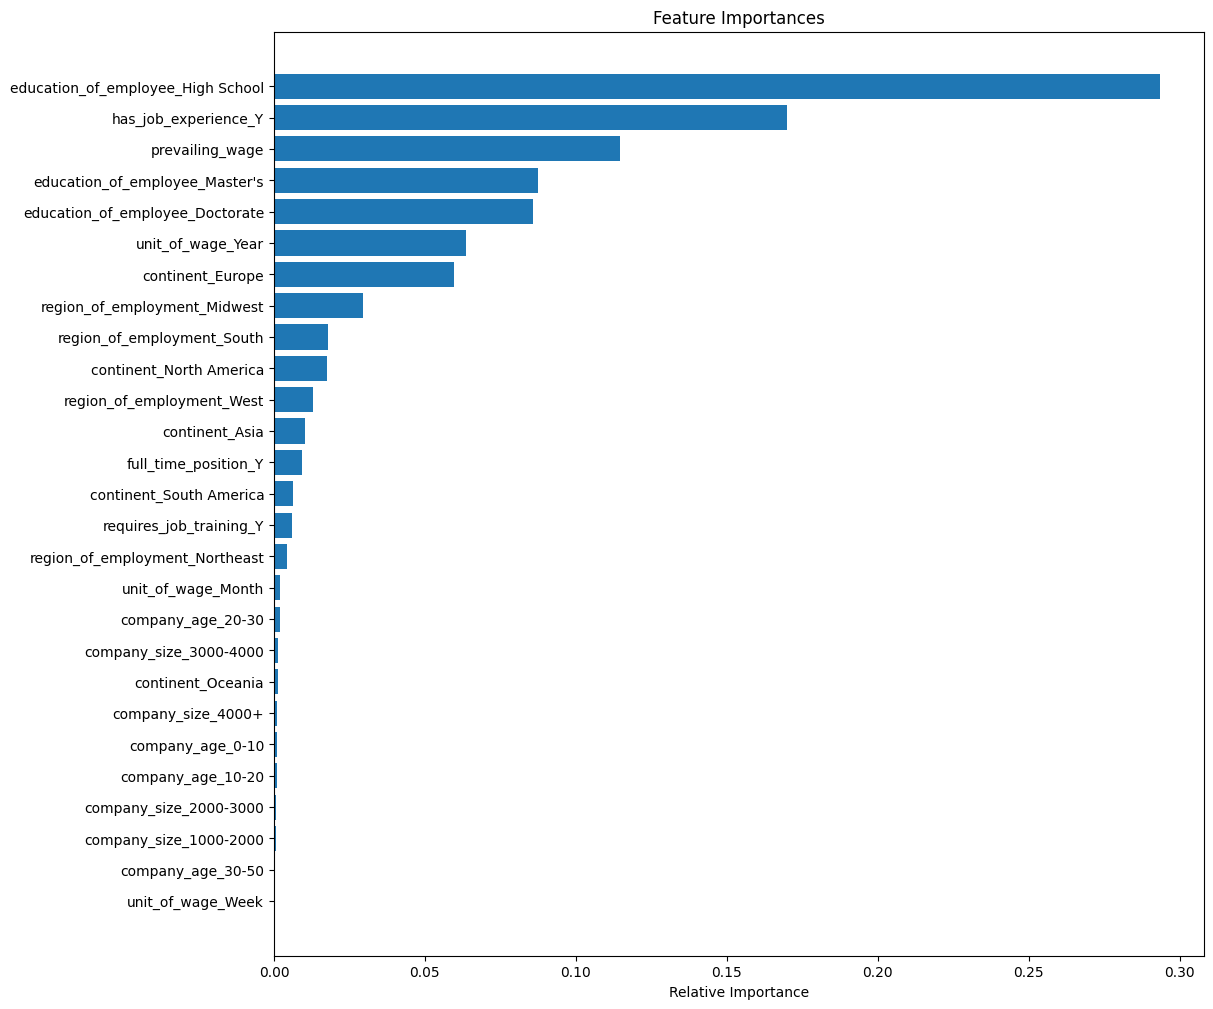

In [136]:
importances = gbc.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Visualization of Decision Tree (tuned)

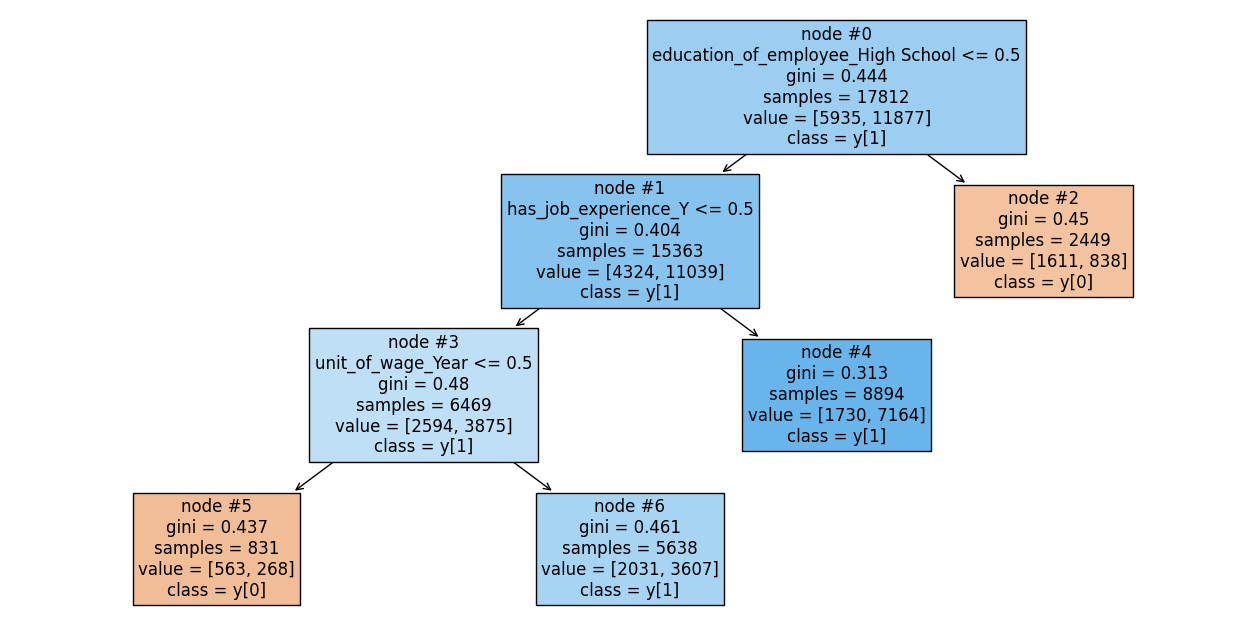

In [137]:
#create visualization of tuned decision-tree model
feature_names = list(X.columns)
plt.figure(figsize=(16,8))
tree.plot_tree(dtree_estimator,feature_names=feature_names,filled=True,fontsize=12,node_ids=True,class_names=True)
plt.show()

## Conclusions

#### Insights
For the Office of Foreign Labor Certification (OFLC), the three most critical components for pre-screening an applicant are:
* *Education level*
    * An applicant applying for a job requiring a high school diploma will more than likely be denied. Conversely, applications for jobs requiring a Master's degree or doctorate are very likely to be approved.
* *Prior job experience*
    * An applicant applying for a job without any previous job experience is more likley to be denied than an applicant for a job with experience.
* *Prevailing wage*
    * The higher the prevailing wage of the job an applicant is applying for, the more likely the application will be approved. This is especially true for applications for jobs with an hourly unit of wage.
    
#### Recommendations
* To prioritize limited resources towards screening a batch of applications for those most likely to be approved, the OFLC can:
    * Sort applications by level of education and review the higher levels of education first.
    * Sort applications by previous job experience and review those with experience first.
    * Divide applications for jobs into those with an hourly wage and those with an annual wage, sort each group by the prevailing wage, then review applications for salaried jobs first from highest to lowest wage.
* As stated previously, the Gradient Boosting classifier performs the best of all the models created. However, as shown above, the tuned Decision-Tree model performs barely worse by F1 score and is a far simpler model. This model may be preferable if post-hoc explanations of OFLC decision-making is expected to be required.
    * Furthermore, OFLC should examine more thoroughly why whether an application will be certified or denied can be very well predicted through just three nodes as shown above.
    * For those in less skilled, entry-level, and/or hourly jobs, the system would appear to be biased against these applications being certified.